In [2]:
import sys
print(sys.executable)


C:\Users\ASUS VIVOBOOK\anaconda3\envs\thesis_env\python.exe


In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupKFold
from lifelines import CoxTimeVaryingFitter
from lifelines.utils import concordance_index
import matplotlib.pyplot as plt


In [4]:
df = pd.read_csv("sliding_windows_1s_clean.csv")
df.head()

,Id,Condition,Map,event_id,window_index,is_partial_window,start_time,end_time,window_size_sec,event_category,...,TTC_mean,TTC_delta,TrafficLight_prev,TrafficLight_current,yellow_transition,prev_phase,current_phase,transition_phase,first_feedback_relavet_to_event,feedback_next_1s
0,C1_036248,Avatar,B,C1_036248__Avatar__traffic light 1,0,0,0.0,1.0,1,TrafficLights,...,5.944003,0.1750,Green,Green,0,Approaching,Approaching,0,0,0
1,C1_036248,Avatar,B,C1_036248__Avatar__traffic light 1,1,0,1.0,2.0,1,TrafficLights,...,6.003409,-0.1380,Green,Green,0,Approaching,Approaching,0,0,0
2,C1_036248,Avatar,B,C1_036248__Avatar__traffic light 1,2,0,2.0,3.0,1,TrafficLights,...,5.566881,-0.6316,Green,Green,0,Approaching,Approaching,0,0,0
3,C1_036248,Avatar,B,C1_036248__Avatar__traffic light 1,3,0,3.0,4.0,1,TrafficLights,...,4.781902,-0.7660,Green,Green,0,Approaching,Approaching,0,0,0
4,C1_036248,Avatar,B,C1_036248__Avatar__traffic light 1,4,0,4.0,5.0,1,TrafficLights,...,3.961193,-0.7344,Green,Green,0,Approaching,Approaching,0,0,0


In [5]:
df.columns

Index(['Id', 'Condition', 'Map', 'event_id', 'window_index',
       'is_partial_window', 'start_time', 'end_time', 'window_size_sec',
       'event_category', 'max_time_since_event_start', 'relevant_object_name',
       'min_distance_from_relevant_object', 'delta_distance', 'Brake_max',
       'Braking_rate', 'Acceleration_max', 'Acceleration_min',
       'Accelerating_rate', 'Speed_mean', 'Speed_max', 'Speed_std',
       'Speed_delta', 'is_stopped', 'SteeringAngle_absmax',
       'SteeringAngle_std', 'TTC_min', 'TTC_mean', 'TTC_delta',
       'TrafficLight_prev', 'TrafficLight_current', 'yellow_transition',
       'prev_phase', 'current_phase', 'transition_phase',
       'first_feedback_relavet_to_event', 'feedback_next_1s'],
      dtype='object')

In [6]:
#Note: before changing to lowercase, some event_ids had traffic and some Traffic
# יש אירועים שכתובים פעם עם אות גדולה ופעם עם קטנה
df["event_id"] = df["event_id"].str.lower()

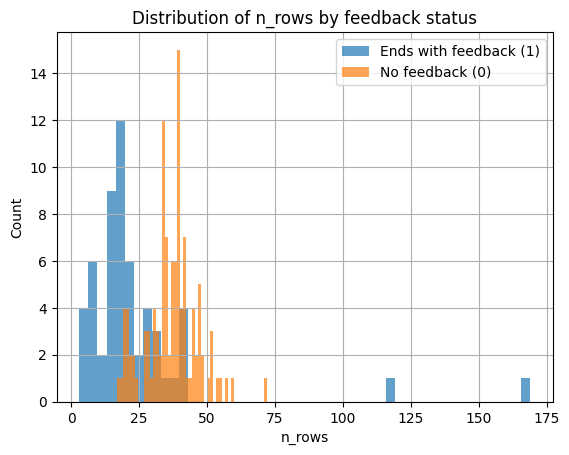

In [34]:
summary = df.groupby("event_id").agg(
    n_rows=("feedback_next_1s", "size"),
    ends_with_feedback=("feedback_next_1s", lambda x: int(x.any()))
).reset_index()

fig, ax = plt.subplots()

summary[summary['ends_with_feedback'] == 1].n_rows.hist(bins=50, ax=ax, label='Ends with feedback (1)', alpha=0.7)
summary[summary['ends_with_feedback'] == 0].n_rows.hist(bins=50, ax=ax, label='No feedback (0)', alpha=0.7)

ax.legend()
plt.xlabel('n_rows')
plt.ylabel('Count')
plt.title('Distribution of n_rows by feedback status')
plt.show()

In [35]:
summary[(summary.ends_with_feedback==0)&(summary.n_rows<3)]

# Check how come there are events of 2 seconds -maybe these are noise

,event_id,n_rows,ends_with_feedback


In [36]:
summary[(summary.ends_with_feedback==1)&(summary.n_rows<2)]
# Better to check that these events' feedbacks are real feedbacks - they occur after 1 second....

,event_id,n_rows,ends_with_feedback


In [37]:
# remove event_ids with feedback within less than 1 second or events shorter than 2 seconds if there is no feedback 
print("before: ", df.shape)
too_short_events = list(summary[((summary.ends_with_feedback==1)&(summary.n_rows<2))|((summary.ends_with_feedback==0)&(summary.n_rows<3))].event_id)
df = df[~df["event_id"].isin(too_short_events)]
print("after: ",df.shape)

before:  (5555, 37)
after:  (5555, 37)


# Creating a dataset of window size n 
### feedback horizon m

In [11]:
# def create_n_second_windows(df, n=5, feedback_horizon=1):
#     numeric_cols = [
#         'min_distance_from_relevant_object', 'delta_distance',
#         'Brake_max', 'Braking_rate', 'Acceleration_max', 'Acceleration_min', 'Accelerating_rate',
#         'Speed_mean', 'Speed_max', 'Speed_std', 'Speed_delta',
#         'is_stopped', 'SteeringAngle_absmax', 'SteeringAngle_std',
#         'TTC_min', 'TTC_mean', 'TTC_delta',
#         'yellow_transition', 'transition_phase'
#     ]
#     categorical_cols = ['TrafficLight_prev', 'TrafficLight_current', 'prev_phase', 'current_phase']
#     meta_cols = ['Id', 'Condition', 'Map', 'event_id', 'event_category', 'relevant_object_name']

#     records = []
#     for event_id, edf in df.groupby('event_id'):
#         edf = edf.sort_values('window_index').reset_index(drop=True)
#         n_rows = len(edf)
#         for i in range(0, n_rows, n):
#             chunk = edf.iloc[i:i + n]
#             if len(chunk) < n:  # skip incomplete last window
#                 continue
#             row = {col: chunk[col].iloc[0] for col in meta_cols}
#             row['window_index'] = i // n
#             row['start_time'] = chunk['start_time'].iloc[0]
#             row['end_time'] = chunk['end_time'].iloc[-1]
#             row['window_size_sec'] = n
#             row['max_time_since_event_start'] = chunk['max_time_since_event_start'].iloc[-1]
#             for col in numeric_cols:
#                 row[f'{col}_mean'] = chunk[col].mean()
#                 row[f'{col}_max'] = chunk[col].max()
#                 row[f'{col}_min'] = chunk[col].min()
#                 row[f'{col}_std'] = chunk[col].std()
#             for col in categorical_cols:
#                 row[col] = chunk[col].iloc[-1]
#             next_rows = edf.iloc[i + n: i + n + feedback_horizon]
#             row[f'feedback_next'] = int(next_rows['feedback_next_1s'].any())
#             records.append(row)

#     return pd.DataFrame(records)


In [38]:
def create_n_second_windows(df, n=5, feedback_horizon=1):
    categorical_cols = ['TrafficLight_prev', 'TrafficLight_current', 'prev_phase', 'current_phase']
    meta_cols = ['Id', 'Condition', 'Map', 'event_id', 'event_category', 'relevant_object_name']

    records = []
    for event_id, edf in df.groupby('event_id'):
        edf = edf.sort_values('window_index').reset_index(drop=True)
        n_rows = len(edf)
        for i in range(0, n_rows, n):
            chunk = edf.iloc[i:i + n]
            if len(chunk) < n:
                continue

            row = {col: chunk[col].iloc[0] for col in meta_cols}
            row['window_index'] = i // n
            row['start_time'] = chunk['start_time'].iloc[0]
            row['end_time'] = chunk['end_time'].iloc[-1]
            row['window_size_sec'] = n
            row['max_time_since_event_start'] = chunk['max_time_since_event_start'].iloc[-1]

            # Single meaningful aggregation per column
            row['min_distance_from_relevant_object'] = chunk['min_distance_from_relevant_object'].min()
            row['delta_distance']                    = chunk['min_distance_from_relevant_object'].iloc[-1] - chunk['min_distance_from_relevant_object'].iloc[0]
            row['Brake_max']                         = chunk['Brake_max'].max()
            row['Braking_rate']                      = chunk['Braking_rate'].max()
            row['Acceleration_max']                  = chunk['Acceleration_max'].max()
            row['Acceleration_min']                  = chunk['Acceleration_min'].min()
            row['Accelerating_rate']                 = chunk['Accelerating_rate'].max()
            row['Speed_mean']                        = chunk['Speed_mean'].mean()
            row['Speed_max']                         = chunk['Speed_max'].max()
            row['Speed_std']                         = chunk['Speed_std'].mean()
            row['Speed_delta']                       = chunk['Speed_mean'].iloc[-1] - chunk['Speed_mean'].iloc[0]
            row['is_stopped']                        = chunk['is_stopped'].max()
            row['SteeringAngle_absmax']              = chunk['SteeringAngle_absmax'].max()
            row['SteeringAngle_std']                 = chunk['SteeringAngle_std'].mean()
            row['TTC_min']                           = chunk['TTC_min'].min()
            row['TTC_mean']                          = chunk['TTC_mean'].mean()
            row['TTC_delta']                         = chunk['TTC_mean'].iloc[-1] - chunk['TTC_mean'].iloc[0]
            row['yellow_transition']                 = chunk['yellow_transition'].max()
            row['transition_phase']                  = chunk['transition_phase'].max()

            for col in categorical_cols:
                row[col] = chunk[col].iloc[-1]

            next_rows = edf.iloc[i + n: i + n + feedback_horizon]
            row['feedback_next'] = int(next_rows['feedback_next_1s'].any())
            records.append(row)

    return pd.DataFrame(records)

In [39]:
df_windows = create_n_second_windows(df, n=5, feedback_horizon=3)
print(df_windows.shape)
df_windows.head()

(1040, 35)


,Id,Condition,Map,event_id,event_category,relevant_object_name,window_index,start_time,end_time,window_size_sec,...,TTC_min,TTC_mean,TTC_delta,yellow_transition,transition_phase,TrafficLight_prev,TrafficLight_current,prev_phase,current_phase,feedback_next
0,C1_036248,Avatar,B,c1_036248__avatar__traffic light 1,TrafficLights,traffic.traffic_light 60,0,0.0,5.0,5,...,3.604162,5.251478,-1.982810,0,0,Green,Green,Approaching,Approaching,0
1,C1_036248,Avatar,B,c1_036248__avatar__traffic light 1,TrafficLights,traffic.traffic_light 60,1,5.0,10.0,5,...,1.460697,2.304509,-1.737548,0,0,Green,Green,Approaching,Approaching,0
2,C1_036248,Avatar,B,c1_036248__avatar__traffic light 1,TrafficLights,traffic.traffic_light 60,2,10.0,15.0,5,...,1.172609,1.296283,-0.047366,0,0,Green,Green,Approaching,Approaching,0
3,C1_036248,Avatar,B,c1_036248__avatar__traffic light 1,TrafficLights,traffic.traffic_light 60,3,15.0,20.0,5,...,1.015425,1.256271,-0.376671,0,0,Green,Green,Approaching,Approaching,0
4,C1_036248,Avatar,B,c1_036248__avatar__traffic light 1,TrafficLights,traffic.traffic_light 60,4,20.0,25.0,5,...,0.660174,2398.675251,11799.787080,1,0,Yellow,Red,Approaching,Approaching,0


In [14]:
# Verification
print("Target distribution:")
print(df_windows['feedback_next'].value_counts())
print()

# Spot-check: compare original rows vs aggregated window for one event
sample_event = df_windows['event_id'].iloc[0]
print(f"Spot-check event: {sample_event}")
print("\nOriginal 1s rows (first 10):")
print(df[df['event_id'] == sample_event][['window_index', 'start_time', 'end_time', 'feedback_next_1s']].head(10).to_string())
print("\nAggregated 5s windows:")
print(df_windows[df_windows['event_id'] == sample_event][['window_index', 'start_time', 'end_time', 'feedback_next']].head(5).to_string())

print()
print("NaN counts (should be 0):")
print(df_windows.isnull().sum()[df_windows.isnull().sum() > 0])

Target distribution:
feedback_next
0    1002
1      38
Name: count, dtype: int64

Spot-check event: c1_036248__avatar__traffic light 1

Original 1s rows (first 10):
   window_index  start_time  end_time  feedback_next_1s
0             0         0.0       1.0                 0
1             1         1.0       2.0                 0
2             2         2.0       3.0                 0
3             3         3.0       4.0                 0
4             4         4.0       5.0                 0
5             5         5.0       6.0                 0
6             6         6.0       7.0                 0
7             7         7.0       8.0                 0
8             8         8.0       9.0                 0
9             9         9.0      10.0                 0

Aggregated 5s windows:
   window_index  start_time  end_time  feedback_next
0             0         0.0       5.0              0
1             1         5.0      10.0              0
2             2        10.0      15.

# Spliting the data into train/test by event_id

In [15]:
from sklearn.model_selection import train_test_split

target_col = 'feedback_next'

# Stratified split at the event_id level: each event goes entirely to train or test
event_labels = df_windows.groupby('event_id')[target_col].max().reset_index()
train_events, test_events = train_test_split(
    event_labels['event_id'],
    test_size=0.2,
    random_state=42,
    stratify=event_labels[target_col]
)

train_df = df_windows[df_windows['event_id'].isin(train_events)].copy()
test_df  = df_windows[df_windows['event_id'].isin(test_events)].copy()

print(f"Train: {len(train_df)} rows, {train_df['event_id'].nunique()} events")
print(f"Test:  {len(test_df)} rows, {test_df['event_id'].nunique()} events")
print(f"\nTarget distribution in train:\n{train_df[target_col].value_counts(normalize=True).round(3)}")
print(f"\nTarget distribution in test:\n{test_df[target_col].value_counts(normalize=True).round(3)}")

Train: 838 rows, 134 events
Test:  202 rows, 34 events

Target distribution in train:
feedback_next
0    0.964
1    0.036
Name: proportion, dtype: float64

Target distribution in test:
feedback_next
0    0.96
1    0.04
Name: proportion, dtype: float64


# additional data preparations 
(dummies, excluding varibles...)

In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, roc_auc_score

# Exclude pure metadata; keep Condition/Map as potentially informative features
exclude_cols = {'Id', 'event_id', 'window_index', 'start_time', 'end_time',
                'window_size_sec', 'first_feedback_relavet_to_event', target_col}
feature_cols = [c for c in df_windows.columns if c not in exclude_cols]

X_train = pd.get_dummies(train_df[feature_cols])
X_test  = pd.get_dummies(test_df[feature_cols])
X_test  = X_test.reindex(columns=X_train.columns, fill_value=0)  # align columns after encoding

y_train = train_df[target_col]
y_test  = test_df[target_col]

# rf = RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42)
# rf.fit(X_train, y_train)

# y_pred = rf.predict(X_test)
# y_prob = rf.predict_proba(X_test)[:, 1]

# print(classification_report(y_test, y_pred))
# print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.3f}")

# fig, ax = plt.subplots()
# ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax)
# plt.title('Confusion Matrix')
# plt.show()

# Trying different models: RF, LR, XGBoost

C:\Users\ASUS VIVOBOOK\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ASUS VIVOBOOK\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ASUS VIVOBOOK\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

── Random Forest ──
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       194
           1       0.00      0.00      0.00         8

    accuracy                           0.96       202
   macro avg       0.48      0.50      0.49       202
weighted avg       0.92      0.96      0.94       202

── Logistic Regression ──
              precision    recall  f1-score   support

           0       0.97      0.79      0.88       194
           1       0.09      0.50      0.15         8

    accuracy                           0.78       202
   macro avg       0.53      0.65      0.51       202
weighted avg       0.94      0.78      0.85       202

── XGBoost ──
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       194
           1       0.00      0.00      0.00         8

    accuracy                           0.96       202
   macro avg       0.48      0.50      0.49       202
weighted avg  

C:\Users\ASUS VIVOBOOK\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ASUS VIVOBOOK\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ASUS VIVOBOOK\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

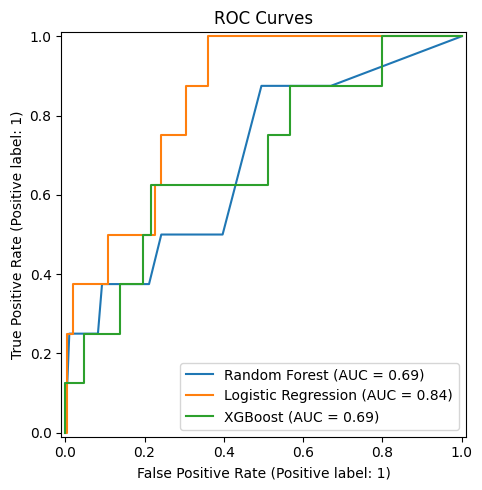

              Model  ROC-AUC  Precision (1)  Recall (1)  F1 (1)
      Random Forest    0.688          0.000         0.0   0.000
Logistic Regression    0.841          0.091         0.5   0.154
            XGBoost    0.691          0.000         0.0   0.000


In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import RocCurveDisplay
from xgboost import XGBClassifier
" אני הוספתי "
rf = RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# Scale features (required for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

models = {
    'Random Forest':      (rf, X_train, X_test),   # already fitted above
    'Logistic Regression': (
        LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
        X_train_scaled, X_test_scaled
    ),
    'XGBoost': (
        XGBClassifier(scale_pos_weight=scale_pos_weight, n_estimators=100,
                      random_state=42, eval_metric='logloss'),
        X_train, X_test
    ),
}

fig, ax = plt.subplots(figsize=(7, 5))
results = []

for name, (model, Xtr, Xte) in models.items():
    if name != 'Random Forest':
        model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)
    y_prob = model.predict_proba(Xte)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    report = classification_report(y_test, y_pred, output_dict=True)
    results.append({
        'Model':     name,
        'ROC-AUC':   round(auc, 3),
        'Precision (1)': round(report['1']['precision'], 3),
        'Recall (1)':    round(report['1']['recall'], 3),
        'F1 (1)':        round(report['1']['f1-score'], 3),
    })
    print(f"── {name} ──")
    print(classification_report(y_test, y_pred))
    RocCurveDisplay.from_predictions(y_test, y_prob, name=name, ax=ax)

ax.set_title('ROC Curves')
plt.tight_layout()
plt.show()

print(pd.DataFrame(results).to_string(index=False))

# Feature selection 
### using two approaches: SelectKBest and L1 regularization

C:\Users\ASUS VIVOBOOK\AppData\Roaming\Python\Python310\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [13 14 26] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\ASUS VIVOBOOK\AppData\Roaming\Python\Python310\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


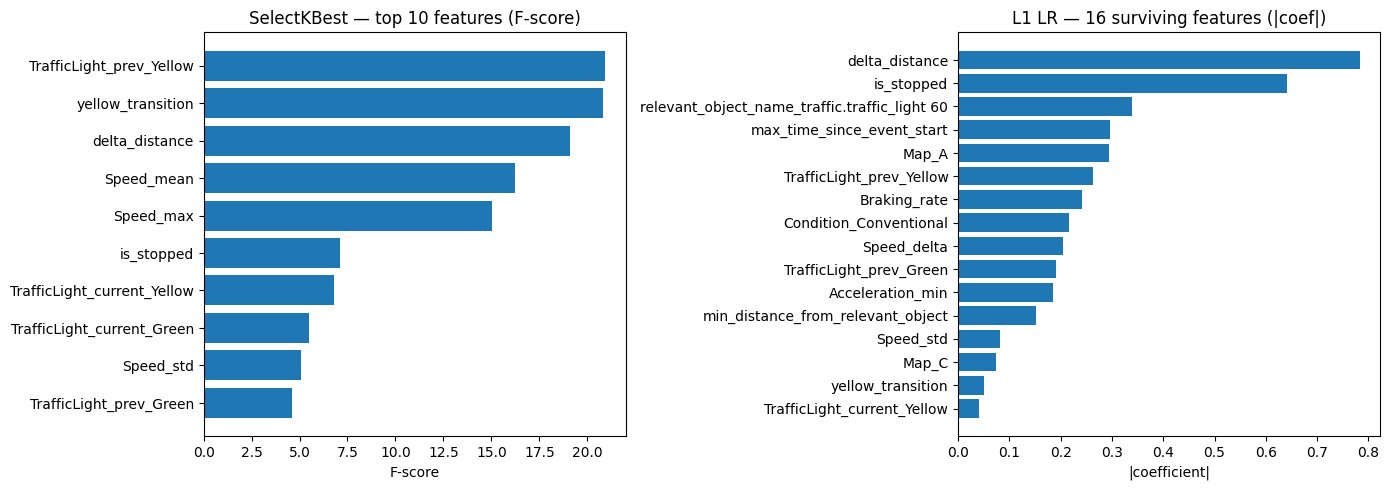

SelectKBest: 10 features
L1 LR:       16 features
Overlap:     7 features — ['Speed_std', 'TrafficLight_current_Yellow', 'TrafficLight_prev_Green', 'TrafficLight_prev_Yellow', 'delta_distance', 'is_stopped', 'yellow_transition']


In [18]:
from sklearn.feature_selection import SelectKBest, f_classif
# K = 25
K = 10
feature_names = X_train.columns.tolist()

# Keep scaled DataFrames so we can index by name
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=feature_names, index=X_train.index)
X_test_scaled_df  = pd.DataFrame(X_test_scaled,  columns=feature_names, index=X_test.index)

# ── Approach 1: SelectKBest (univariate F-test) ──────────────────────────────
selector = SelectKBest(f_classif, k=K)
selector.fit(X_train_scaled_df, y_train)
kbest_features = X_train_scaled_df.columns[selector.get_support()].tolist()

scores_df = pd.DataFrame({'feature': feature_names, 'F_score': selector.scores_})\
              .sort_values('F_score', ascending=False).head(K)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(scores_df['feature'][::-1], scores_df['F_score'][::-1])
axes[0].set_title(f'SelectKBest — top {K} features (F-score)')
axes[0].set_xlabel('F-score')

# ── Approach 2: L1 Logistic Regression ──────────────────────────────────────
lr_l1 = LogisticRegression(penalty='l1', solver='liblinear', C=0.1,
                            class_weight='balanced', random_state=42)
lr_l1.fit(X_train_scaled_df, y_train)
l1_mask     = lr_l1.coef_[0] != 0
l1_features = [f for f, m in zip(feature_names, l1_mask) if m]

coef_df = pd.DataFrame({'feature': feature_names, 'coef': lr_l1.coef_[0]})\
            .query('coef != 0').reindex(
                pd.Series(lr_l1.coef_[0][l1_mask]).abs().sort_values(ascending=False).index
            ).reset_index(drop=True)
coef_df = pd.DataFrame({'feature': l1_features,
                         'abs_coef': abs(lr_l1.coef_[0][l1_mask])})\
            .sort_values('abs_coef', ascending=False)

axes[1].barh(coef_df['feature'][::-1], coef_df['abs_coef'][::-1])
axes[1].set_title(f'L1 LR — {len(l1_features)} surviving features (|coef|)')
axes[1].set_xlabel('|coefficient|')

plt.tight_layout()
plt.show()

overlap = set(kbest_features) & set(l1_features)
print(f"SelectKBest: {len(kbest_features)} features")
print(f"L1 LR:       {len(l1_features)} features")
print(f"Overlap:     {len(overlap)} features — {sorted(overlap)}")

# Testing Feature Selection

── LR — full (baseline) (41 features) ──
              precision    recall  f1-score   support

           0       0.97      0.79      0.88       194
           1       0.09      0.50      0.15         8

    accuracy                           0.78       202
   macro avg       0.53      0.65      0.51       202
weighted avg       0.94      0.78      0.85       202

── LR — SelectKBest (k=10) (10 features) ──
              precision    recall  f1-score   support

           0       0.99      0.68      0.81       194
           1       0.10      0.88      0.18         8

    accuracy                           0.69       202
   macro avg       0.55      0.78      0.49       202
weighted avg       0.96      0.69      0.78       202

── LR — L1 selection (16 features) ──
              precision    recall  f1-score   support

           0       0.98      0.79      0.87       194
           1       0.11      0.62      0.19         8

    accuracy                           0.78       202
   ma

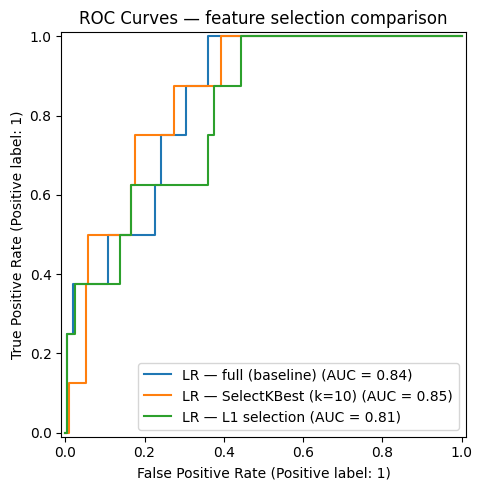

                  Model  n_features  ROC-AUC  Precision (1)  Recall (1)  F1 (1)
   LR — full (baseline)          41    0.841          0.091       0.500   0.154
LR — SelectKBest (k=10)          10    0.853          0.101       0.875   0.182
      LR — L1 selection          16    0.810          0.109       0.625   0.185


In [19]:
# Train LR on each reduced feature set and compare against the full-feature baseline
fig, ax = plt.subplots(figsize=(7, 5))
results_fs = []

feature_sets = {
    'LR — full (baseline)': feature_names,
    f'LR — SelectKBest (k={K})': kbest_features,
    'LR — L1 selection': l1_features,
}

for label, features in feature_sets.items():
    Xtr = X_train_scaled_df[features]
    Xte = X_test_scaled_df[features]
    model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)
    y_prob = model.predict_proba(Xte)[:, 1]
    auc    = roc_auc_score(y_test, y_prob)
    rep    = classification_report(y_test, y_pred, output_dict=True)
    results_fs.append({
        'Model':         label,
        'n_features':    len(features),
        'ROC-AUC':       round(auc, 3),
        'Precision (1)': round(rep['1']['precision'], 3),
        'Recall (1)':    round(rep['1']['recall'], 3),
        'F1 (1)':        round(rep['1']['f1-score'], 3),
    })
    print(f"── {label} ({len(features)} features) ──")
    print(classification_report(y_test, y_pred))
    RocCurveDisplay.from_predictions(y_test, y_prob, name=label, ax=ax)

ax.set_title('ROC Curves — feature selection comparison')
plt.tight_layout()
plt.show()

print(pd.DataFrame(results_fs).to_string(index=False))

# Trying SMOTE

In [20]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled_df, y_train)
print(f"Before SMOTE: {pd.Series(y_train).value_counts().to_dict()}")
print(f"After SMOTE:  {pd.Series(y_train_sm).value_counts().to_dict()}")

# No class_weight — SMOTE already balances the classes
lr_smote = LogisticRegression(max_iter=1000, random_state=42)
lr_smote.fit(X_train_sm, y_train_sm)

y_pred_sm = lr_smote.predict(X_test_scaled_df)
y_prob_sm  = lr_smote.predict_proba(X_test_scaled_df)[:, 1]
print(f"\n── LR + SMOTE ──")
print(classification_report(y_test, y_pred_sm))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_sm):.3f}")

Before SMOTE: {0: 808, 1: 30}
After SMOTE:  {0: 808, 1: 808}

── LR + SMOTE ──
              precision    recall  f1-score   support

           0       0.98      0.83      0.90       194
           1       0.11      0.50      0.18         8

    accuracy                           0.82       202
   macro avg       0.54      0.66      0.54       202
weighted avg       0.94      0.82      0.87       202

ROC-AUC: 0.855


# Find best threshold 
Maximizing F1 score

Optimal threshold — baseline LR: 0.657  (train F1=0.273)
Optimal threshold — SMOTE LR:    0.583  (train F1=0.854)
── LR baseline — default (0.5) (threshold=0.500) ──
              precision    recall  f1-score   support

           0       0.97      0.79      0.88       194
           1       0.09      0.50      0.15         8

    accuracy                           0.78       202
   macro avg       0.53      0.65      0.51       202
weighted avg       0.94      0.78      0.85       202

── LR baseline — tuned threshold (threshold=0.657) ──
              precision    recall  f1-score   support

           0       0.98      0.89      0.93       194
           1       0.15      0.50      0.24         8

    accuracy                           0.87       202
   macro avg       0.57      0.69      0.58       202
weighted avg       0.94      0.87      0.90       202

── LR SMOTE — default (0.5) (threshold=0.500) ──
              precision    recall  f1-score   support

           0       0.9

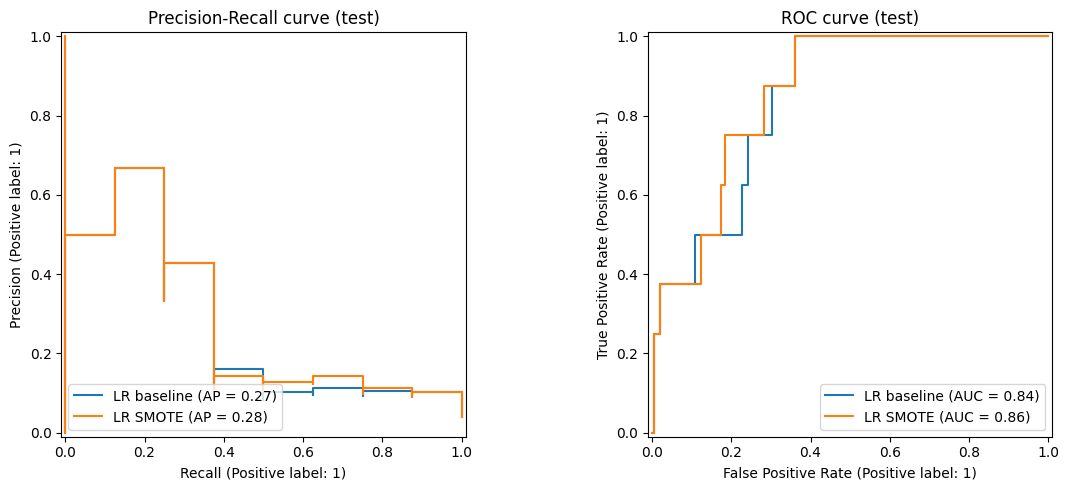

                        Model  Threshold  ROC-AUC  Precision (1)  Recall (1)  F1 (1)
  LR baseline — default (0.5)      0.500    0.841          0.091         0.5   0.154
LR baseline — tuned threshold      0.657    0.841          0.154         0.5   0.235
     LR SMOTE — default (0.5)      0.500    0.855          0.108         0.5   0.178
   LR SMOTE — tuned threshold      0.583    0.855          0.133         0.5   0.211


In [21]:
from sklearn.metrics import precision_recall_curve, PrecisionRecallDisplay

# Re-train baseline LR (full features, class_weight balanced) for a clean reference
lr_base = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_base.fit(X_train_scaled_df, y_train)

def find_best_threshold(model, X, y):
    """Threshold on X/y that maximises F1 for the positive class."""
    probs = model.predict_proba(X)[:, 1]
    precisions, recalls, thresholds = precision_recall_curve(y, probs)
    f1s = 2 * precisions[:-1] * recalls[:-1] / (precisions[:-1] + recalls[:-1] + 1e-9)
    best_idx = f1s.argmax()
    return thresholds[best_idx], f1s[best_idx]

thresh_base,  f1_base  = find_best_threshold(lr_base,  X_train_scaled_df, y_train)
thresh_smote, f1_smote = find_best_threshold(lr_smote, X_train_sm,        y_train_sm)
print(f"Optimal threshold — baseline LR: {thresh_base:.3f}  (train F1={f1_base:.3f})")
print(f"Optimal threshold — SMOTE LR:    {thresh_smote:.3f}  (train F1={f1_smote:.3f})")

# ── Evaluate on test with tuned thresholds ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
results_thresh = []

configs = [
    ('LR baseline — default (0.5)',  lr_base,  X_test_scaled_df, 0.5),
    ('LR baseline — tuned threshold', lr_base,  X_test_scaled_df, thresh_base),
    ('LR SMOTE — default (0.5)',      lr_smote, X_test_scaled_df, 0.5),
    ('LR SMOTE — tuned threshold',    lr_smote, X_test_scaled_df, thresh_smote),
]

for i, (label, model, Xte, thresh) in enumerate(configs):
    y_prob = model.predict_proba(Xte)[:, 1]
    y_pred = (y_prob >= thresh).astype(int)
    rep = classification_report(y_test, y_pred, output_dict=True)
    results_thresh.append({
        'Model':         label,
        'Threshold':     round(thresh, 3),
        'ROC-AUC':       round(roc_auc_score(y_test, y_prob), 3),
        'Precision (1)': round(rep['1']['precision'], 3),
        'Recall (1)':    round(rep['1']['recall'], 3),
        'F1 (1)':        round(rep['1']['f1-score'], 3),
    })
    print(f"── {label} (threshold={thresh:.3f}) ──")
    print(classification_report(y_test, y_pred))

# PR curves
for model, label, X, y in [
    (lr_base,  'LR baseline', X_test_scaled_df, y_test),
    (lr_smote, 'LR SMOTE',    X_test_scaled_df, y_test),
]:
    PrecisionRecallDisplay.from_estimator(model, X, y, name=label, ax=axes[0])
axes[0].set_title('Precision-Recall curve (test)')

# ROC curves
for model, label, X in [
    (lr_base,  'LR baseline', X_test_scaled_df),
    (lr_smote, 'LR SMOTE',    X_test_scaled_df),
]:
    RocCurveDisplay.from_estimator(model, X, y_test, name=label, ax=axes[1])
axes[1].set_title('ROC curve (test)')

plt.tight_layout()
plt.show()

print(pd.DataFrame(results_thresh).to_string(index=False))

In [22]:
from sklearn.base import clone
from sklearn.model_selection import StratifiedGroupKFold

def run_pipeline(df, n=5, feedback_horizon=3, model=None, k=5,
                 use_l1_selection=False, l1_C=0.1):
    """
    Full classification pipeline with grouped k-fold CV.

    Parameters
    ----------
    df                : cleaned DataFrame (after removing too-short events)
    n                 : window size in seconds
    feedback_horizon  : seconds after window to look for feedback
    model             : sklearn estimator; defaults to LR with class_weight='balanced'
    k                 : number of CV folds
    use_l1_selection  : if True, select features via L1 LR before fitting model
    l1_C              : regularisation strength for L1 selection (smaller = fewer features)
    """
    if model is None:
        model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

    # ── 1. Build dataset ────────────────────────────────────────────────────
    df_w = create_n_second_windows(df, n=n, feedback_horizon=feedback_horizon)
    target_col = 'feedback_next'

    exclude = {'Id', 'event_id', 'window_index', 'start_time', 'end_time',
               'window_size_sec', 'first_feedback_relavet_to_event', target_col}
    feat_cols = [c for c in df_w.columns if c not in exclude]

    X_all = pd.get_dummies(df_w[feat_cols])
    X_all = X_all.fillna(0)  # std() of a single row is NaN (e.g. n=1)
    y_all = df_w[target_col].values
    groups = df_w['event_id'].values

    print(f"Dataset: {len(df_w)} rows | {df_w['event_id'].nunique()} events | "
          f"positive rate: {y_all.mean():.1%}")
    print(f"Settings: n={n}s, horizon={feedback_horizon}s, k={k}, "
          f"L1={'yes (C=' + str(l1_C) + ')' if use_l1_selection else 'no'}\n")

    # ── 2. Cross-validation ─────────────────────────────────────────────────
    cv = StratifiedGroupKFold(n_splits=k)
    fold_records = []

    for fold, (tr_idx, te_idx) in enumerate(cv.split(X_all, y_all, groups)):
        X_tr, X_te = X_all.iloc[tr_idx], X_all.iloc[te_idx]
        y_tr, y_te = y_all[tr_idx], y_all[te_idx]

        # Scale (fit on train only)
        scaler = StandardScaler()
        X_tr_s = pd.DataFrame(scaler.fit_transform(X_tr), columns=X_tr.columns)
        X_te_s = pd.DataFrame(scaler.transform(X_te),     columns=X_te.columns)

        # Optional L1 feature selection (fit on train only)
        if use_l1_selection:
            sel = LogisticRegression(penalty='l1', solver='liblinear', C=l1_C,
                                     class_weight='balanced', random_state=42)
            sel.fit(X_tr_s, y_tr)
            mask = sel.coef_[0] != 0
            if mask.sum() == 0:
                mask = np.ones(len(mask), dtype=bool)  # fallback: keep all
            selected = X_tr_s.columns[mask].tolist()
            X_tr_s, X_te_s = X_tr_s[selected], X_te_s[selected]
        else:
            selected = X_tr_s.columns.tolist()

        # Skip fold if test has no positives (AUC undefined)
        if y_te.sum() == 0:
            print(f"  Fold {fold+1}: no positives in test — skipped")
            continue

        # Train
        m = clone(model)
        m.fit(X_tr_s, y_tr)

        y_prob_te = m.predict_proba(X_te_s)[:, 1]
        auc = roc_auc_score(y_te, y_prob_te)

        # Best threshold: optimise F1 on train predictions
        y_prob_tr = m.predict_proba(X_tr_s)[:, 1]
        prec_tr, rec_tr, thresh_tr = precision_recall_curve(y_tr, y_prob_tr)
        f1_tr = 2 * prec_tr[:-1] * rec_tr[:-1] / (prec_tr[:-1] + rec_tr[:-1] + 1e-9)
        best_t = thresh_tr[f1_tr.argmax()]

        # Evaluate at both thresholds
        for t_label, t in [('default (0.5)', 0.5), ('tuned', best_t)]:
            y_pred = (y_prob_te >= t).astype(int)
            rep = classification_report(y_te, y_pred, output_dict=True, zero_division=0)
            fold_records.append({
                'fold':       fold + 1,
                'threshold':  t_label,
                'thresh_val': round(t, 3),
                'n_features': len(selected),
                'ROC-AUC':    round(auc, 3),
                'Precision':  round(rep['1']['precision'], 3),
                'Recall':     round(rep['1']['recall'], 3),
                'F1':         round(rep['1']['f1-score'], 3),
            })

    # ── 3. Summary ──────────────────────────────────────────────────────────
    folds_df = pd.DataFrame(fold_records)
    metrics  = ['ROC-AUC', 'Precision', 'Recall', 'F1']

    summary_rows = []
    for t_label in folds_df['threshold'].unique():
        sub = folds_df[folds_df['threshold'] == t_label]
        avg_thresh = sub['thresh_val'].mean()
        label = t_label if t_label == 'default (0.5)' else f'tuned (avg {avg_thresh:.2f})'
        for metric in metrics:
            summary_rows.append({
                'Threshold': label,
                'Metric':    metric,
                'Mean':      round(sub[metric].mean(), 3),
                'SD':        round(sub[metric].std(),  3),
            })

    summary = pd.DataFrame(summary_rows)
    pivot   = summary.pivot_table(index='Metric', columns='Threshold',
                                  values=['Mean', 'SD'], aggfunc='first')
    print(pivot.to_string())

    if use_l1_selection:
        print(f"\nFeatures selected per fold: "
              f"{folds_df['n_features'].mean():.1f} ± {folds_df['n_features'].std():.1f}")

    return folds_df, summary


# ── Example usage ────────────────────────────────────────────────────────────
folds_df, summary = run_pipeline(df, n=5, feedback_horizon=3, k=5)

Dataset: 1040 rows | 168 events | positive rate: 3.7%
Settings: n=5s, horizon=3s, k=5, L1=no

                   Mean                             SD                 
Threshold default (0.5) tuned (avg 0.69) default (0.5) tuned (avg 0.69)
Metric                                                                 
F1                0.137            0.124         0.024            0.093
Precision         0.080            0.078         0.014            0.058
ROC-AUC           0.730            0.730         0.071            0.071
Recall            0.503            0.311         0.080            0.233


In [23]:
# Default run
run_pipeline(df, n=5, feedback_horizon=3, k=5)

# With L1 selection and XGBoost
# run_pipeline(df, n=5, feedback_horizon=3,
#              model=XGBClassifier(scale_pos_weight=15, random_state=42),
#              k=5, use_l1_selection=False, l1_C=0.1)

Dataset: 1040 rows | 168 events | positive rate: 3.7%
Settings: n=5s, horizon=3s, k=5, L1=no

                   Mean                             SD                 
Threshold default (0.5) tuned (avg 0.69) default (0.5) tuned (avg 0.69)
Metric                                                                 
F1                0.137            0.124         0.024            0.093
Precision         0.080            0.078         0.014            0.058
ROC-AUC           0.730            0.730         0.071            0.071
Recall            0.503            0.311         0.080            0.233


(   fold      threshold  thresh_val  n_features  ROC-AUC  Precision  Recall  \
 0     1  default (0.5)       0.500          42    0.834      0.093   0.571   
 1     1          tuned       0.763          42    0.834      0.000   0.000   
 2     2  default (0.5)       0.500          42    0.663      0.089   0.571   
 3     2          tuned       0.641          42    0.663      0.094   0.429   
 4     3  default (0.5)       0.500          42    0.762      0.077   0.500   
 5     3          tuned       0.656          42    0.762      0.138   0.500   
 6     4  default (0.5)       0.500          42    0.667      0.057   0.375   
 7     4          tuned       0.702          42    0.667      0.037   0.125   
 8     5  default (0.5)       0.500          42    0.726      0.082   0.500   
 9     5          tuned       0.712          42    0.726      0.121   0.500   
 
       F1  
 0  0.160  
 1  0.000  
 2  0.154  
 3  0.154  
 4  0.133  
 5  0.216  
 6  0.098  
 7  0.057  
 8  0.140  
 9  0.195

# Grid Search: Window Size (1–5s) × Prediction Horizon (1–3s)
### Comparing all 15 combinations and finding the best configuration

Running: window=1s, horizon=1s ...
Dataset: 5555 rows | 170 events | positive rate: 1.0%
Settings: n=1s, horizon=1s, k=5, L1=no

                   Mean                             SD                 
Threshold default (0.5) tuned (avg 0.82) default (0.5) tuned (avg 0.82)
Metric                                                                 
F1                0.044            0.041         0.016            0.038
Precision         0.023            0.023         0.008            0.021
ROC-AUC           0.685            0.685         0.073            0.073
Recall            0.550            0.200         0.176            0.186

Running: window=1s, horizon=2s ...
Dataset: 5555 rows | 170 events | positive rate: 2.0%
Settings: n=1s, horizon=2s, k=5, L1=no

                   Mean                             SD                 
Threshold default (0.5) tuned (avg 0.73) default (0.5) tuned (avg 0.73)
Metric                                                                 
F1                0.0

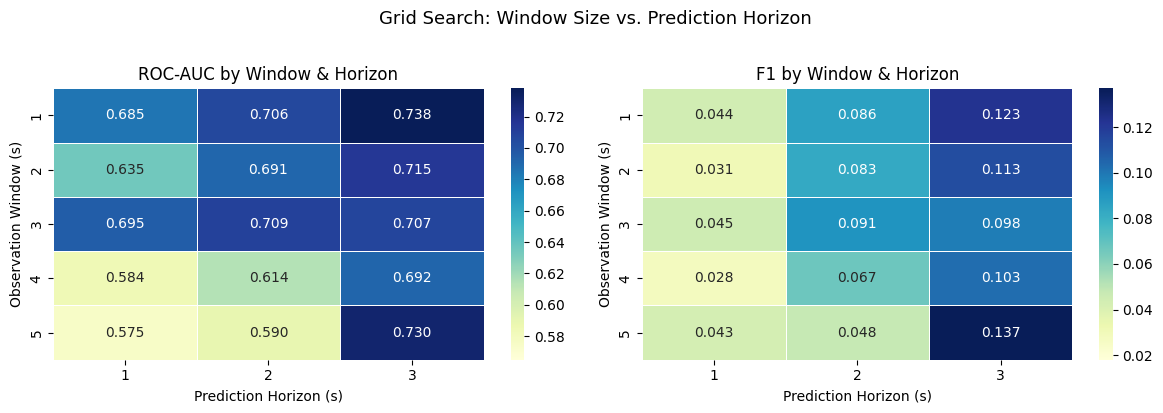

In [24]:
import warnings
warnings.filterwarnings("ignore")

window_sizes   = [1, 2, 3, 4, 5]
horizons       = [1, 2, 3]

grid_results = []

for n in window_sizes:
    for h in horizons:
        print(f"Running: window={n}s, horizon={h}s ...")
        folds_df, summary_df = run_pipeline(df, n=n, feedback_horizon=h, k=5,
                                             use_l1_selection=False)

        # Extract mean metrics at default threshold (0.5)
        sub = summary_df[summary_df["Threshold"] == "default (0.5)"].set_index("Metric")
        grid_results.append({
            "Window (s)":    n,
            "Horizon (s)":   h,
            "ROC-AUC":       sub.loc["ROC-AUC",  "Mean"],
            "AUC SD":        sub.loc["ROC-AUC",  "SD"],
            "Recall":        sub.loc["Recall",   "Mean"],
            "Precision":     sub.loc["Precision","Mean"],
            "F1":            sub.loc["F1",       "Mean"],
            "F1 SD":         sub.loc["F1",       "SD"],
        })
        print()

grid_df = pd.DataFrame(grid_results).round(3)

# ── Full comparison table ───────────────────────────────────────────
print("=" * 75)
print("FULL COMPARISON TABLE")
print("=" * 75)
print(grid_df.to_string(index=False))

# ── Best configuration ──────────────────────────────────────────────
best_auc = grid_df.loc[grid_df["ROC-AUC"].idxmax()]
best_f1  = grid_df.loc[grid_df["F1"].idxmax()]

print()
print("=" * 75)
print("BEST CONFIGURATION")
print("=" * 75)
print(f"Best ROC-AUC: window={int(best_auc['Window (s)'])}s, horizon={int(best_auc['Horizon (s)'])}s",
      f"-> AUC={best_auc['ROC-AUC']:.3f} (±{best_auc['AUC SD']:.3f})")
print(f"Best F1:      window={int(best_f1['Window (s)'])}s, horizon={int(best_f1['Horizon (s)'])}s",
      f"-> F1={best_f1['F1']:.3f} (±{best_f1['F1 SD']:.3f})")

# ── Heatmaps ────────────────────────────────────────────────────────
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, metric in zip(axes, ["ROC-AUC", "F1"]):
    pivot = grid_df.pivot(index="Window (s)", columns="Horizon (s)", values=metric)
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap="YlGnBu", ax=ax,
                linewidths=0.5, vmin=grid_df[metric].min() - 0.01)
    ax.set_title(f"{metric} by Window & Horizon")
    ax.set_xlabel("Prediction Horizon (s)")
    ax.set_ylabel("Observation Window (s)")

plt.suptitle("Grid Search: Window Size vs. Prediction Horizon", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


# One predictor: does Time-to-Collision alone predict feedback?

## Exploratory Analysis: TTC_min vs. Feedback
### Do windows with lower TTC have higher feedback rates?

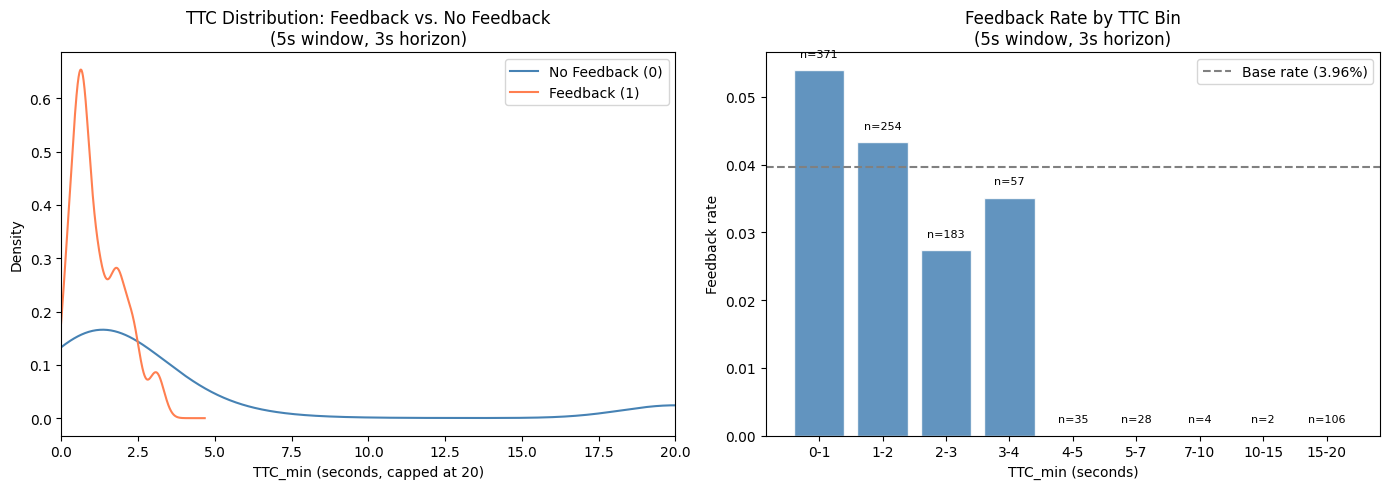

TTC_bin  n_windows  n_feedback  feedback_rate
    0-1        371          20       0.053908
    1-2        254          11       0.043307
    2-3        183           5       0.027322
    3-4         57           2       0.035088
    4-5         35           0       0.000000
    5-7         28           0       0.000000
   7-10          4           0       0.000000
  10-15          2           0       0.000000
  15-20        106           0       0.000000


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_5s = df_windows.copy()
df_5s["TTC_capped"] = df_5s["TTC_min"].clip(upper=20)
# ── 1. Density plot (KDE) ─────────────────────────────────────────────
fb0 = df_5s.loc[df_5s.feedback_next == 0, "TTC_capped"]
fb1 = df_5s.loc[df_5s.feedback_next == 1, "TTC_capped"]

fb0.plot.kde(ax=axes[0], label="No Feedback (0)", color="steelblue", bw_method=0.3)
fb1.plot.kde(ax=axes[0], label="Feedback (1)",    color="coral",     bw_method=0.3)
axes[0].set_xlabel("TTC_min (seconds, capped at 20)")
axes[0].set_ylabel("Density")
axes[0].set_title("TTC Distribution: Feedback vs. No Feedback\n(5s window, 3s horizon)")
axes[0].set_xlim(0, 20)
axes[0].legend()

# ── 2. Binned feedback rate ───────────────────────────────────────────
bins   = [0, 1, 2, 3, 4, 5, 7, 10, 15, 20]
labels = ["0-1", "1-2", "2-3", "3-4", "4-5", "5-7", "7-10", "10-15", "15-20"]

df_5s["TTC_bin"] = pd.cut(df_5s["TTC_capped"], bins=bins, labels=labels)

bin_stats = df_5s.groupby("TTC_bin", observed=True).agg(
    n_windows   = ("feedback_next", "count"),
    n_feedback  = ("feedback_next", "sum"),
    feedback_rate = ("feedback_next", "mean")
).reset_index()

axes[1].bar(bin_stats["TTC_bin"], bin_stats["feedback_rate"],
            color="steelblue", edgecolor="white", alpha=0.85)
axes[1].axhline(y.mean(), color="gray", linestyle="--",
                label="Base rate (" + str(round(y.mean()*100, 2)) + "%)")
axes[1].set_xlabel("TTC_min (seconds)")
axes[1].set_ylabel("Feedback rate")
axes[1].set_title("Feedback Rate by TTC Bin\n(5s window, 3s horizon)")
axes[1].legend()

# Add count labels on bars
for _, row in bin_stats.iterrows():
    axes[1].text(row["TTC_bin"], row["feedback_rate"] + 0.002,
                 f'n={int(row["n_windows"])}', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

print(bin_stats.to_string(index=False))

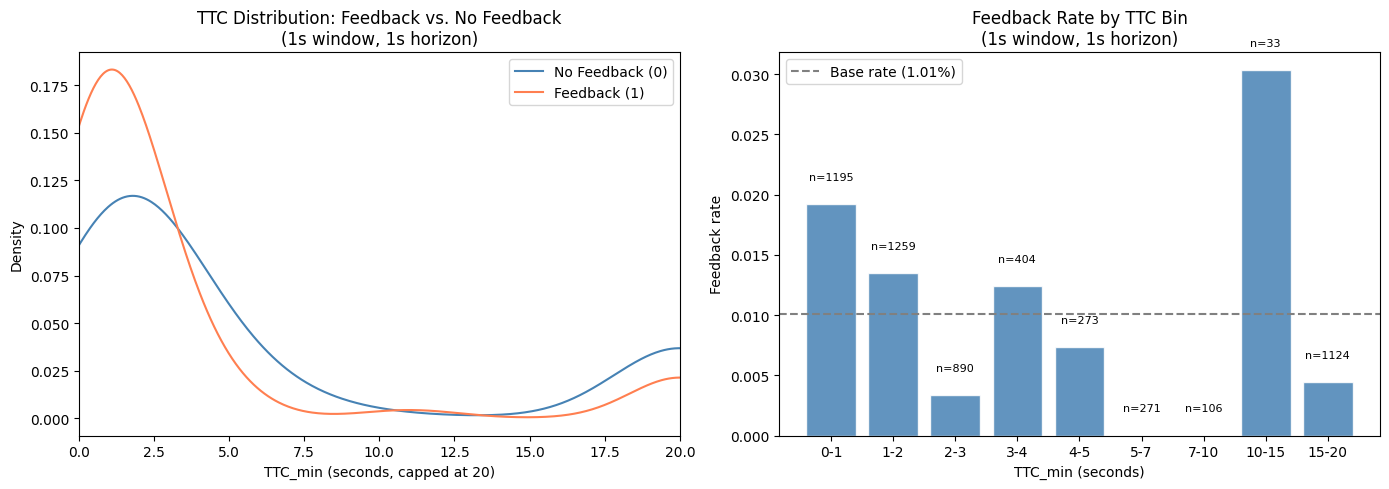

TTC_bin  n_windows  n_feedback  feedback_rate
    0-1       1195          23       0.019247
    1-2       1259          17       0.013503
    2-3        890           3       0.003371
    3-4        404           5       0.012376
    4-5        273           2       0.007326
    5-7        271           0       0.000000
   7-10        106           0       0.000000
  10-15         33           1       0.030303
  15-20       1124           5       0.004448


In [26]:
df_1s_windows = create_n_second_windows(df, n=1, feedback_horizon=1)
df_1s_windows["TTC_capped"] = df_1s_windows["TTC_min"].clip(upper=20)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── 1. Density plot (KDE) ─────────────────────────────────────────────
fb0 = df_1s_windows.loc[df_1s_windows.feedback_next == 0, "TTC_capped"]
fb1 = df_1s_windows.loc[df_1s_windows.feedback_next == 1, "TTC_capped"]

fb0.plot.kde(ax=axes[0], label="No Feedback (0)", color="steelblue", bw_method=0.3)
fb1.plot.kde(ax=axes[0], label="Feedback (1)",    color="coral",     bw_method=0.3)
axes[0].set_xlabel("TTC_min (seconds, capped at 20)")
axes[0].set_ylabel("Density")
axes[0].set_title("TTC Distribution: Feedback vs. No Feedback\n(1s window, 1s horizon)")
axes[0].set_xlim(0, 20)
axes[0].legend()

# ── 2. Binned feedback rate ───────────────────────────────────────────
bins   = [0, 1, 2, 3, 4, 5, 7, 10, 15, 20]
labels = ["0-1", "1-2", "2-3", "3-4", "4-5", "5-7", "7-10", "10-15", "15-20"]

df_1s_windows["TTC_bin"] = pd.cut(df_1s_windows["TTC_capped"], bins=bins, labels=labels)

bin_stats = df_1s_windows.groupby("TTC_bin", observed=True).agg(
    n_windows     = ("feedback_next", "count"),
    n_feedback    = ("feedback_next", "sum"),
    feedback_rate = ("feedback_next", "mean")
).reset_index()

axes[1].bar(bin_stats["TTC_bin"], bin_stats["feedback_rate"],
            color="steelblue", edgecolor="white", alpha=0.85)
axes[1].axhline(df_1s_windows["feedback_next"].mean(), color="gray", linestyle="--",
                label="Base rate (" + str(round(df_1s_windows["feedback_next"].mean()*100, 2)) + "%)")
axes[1].set_xlabel("TTC_min (seconds)")
axes[1].set_ylabel("Feedback rate")
axes[1].set_title("Feedback Rate by TTC Bin\n(1s window, 1s horizon)")
axes[1].legend()

for _, row in bin_stats.iterrows():
    axes[1].text(row["TTC_bin"], row["feedback_rate"] + 0.002,
                 f'n={int(row["n_windows"])}', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

print(bin_stats.to_string(index=False))

N rows: 5568 | Positive rate: 1.01 %
TTC_log: mean = 1.45  median = 1.19

LOGISTIC REGRESSION -- log(TTC) only (full data)
         Coefficient (B)      OR  OR CI lower  OR CI upper  p-value
const            -4.0610  0.0172       0.0108       0.0275   0.0000
TTC_log          -0.4079  0.6651       0.4761       0.9290   0.0168

Cross-validated ROC-AUC (5-fold, grouped by participant):
  Mean = 0.624  | SD = 0.125


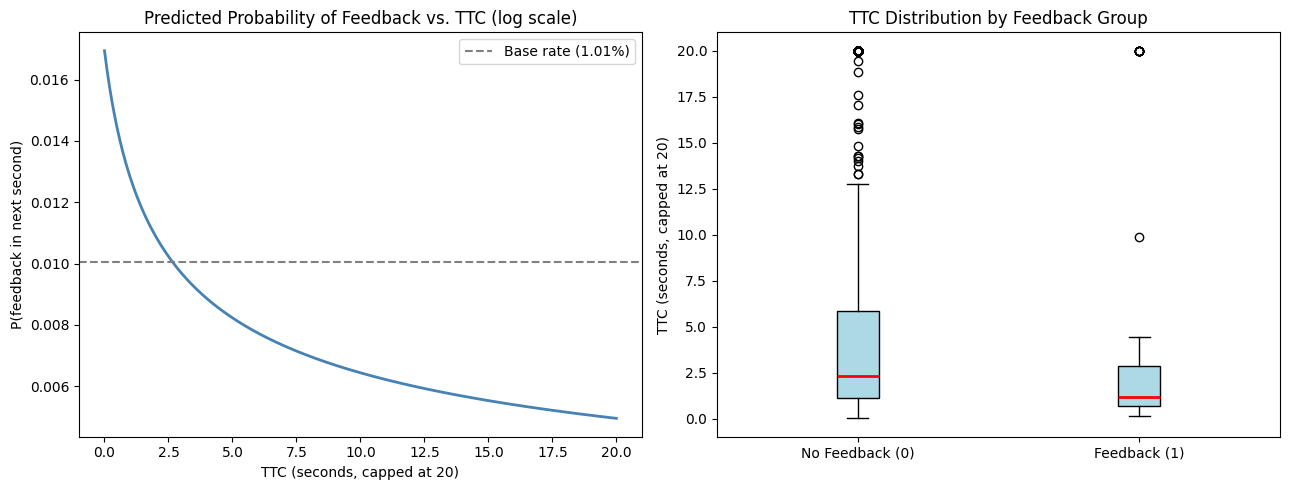

TTC mean -- No Feedback: 5.88 s | Feedback: 4.47 s
Mann-Whitney U test: p = 0.0014


In [27]:
import statsmodels.api as sm
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import roc_auc_score
from scipy.stats import mannwhitneyu
import warnings
warnings.filterwarnings("ignore")

# ── Prepare data ─────────────────────────────────────────────────────
df_1s = pd.read_csv("sliding_windows_1s_clean.csv")
df_1s["event_id"] = df_1s["event_id"].str.lower()

# Cap TTC and apply log transformation
df_1s["TTC_capped"] = df_1s["TTC_min"].clip(upper=20)
df_1s["TTC_log"]    = np.log1p(df_1s["TTC_capped"])  # log(1+x) to avoid log(0)
df_1s = df_1s.dropna(subset=["TTC_log", "feedback_next_1s"])

X = df_1s[["TTC_log"]].values
y = df_1s["feedback_next_1s"].values
groups = df_1s["Id"].values

print("N rows:", len(df_1s), "| Positive rate:", round(y.mean() * 100, 2), "%")
print("TTC_log: mean =", round(df_1s.TTC_log.mean(), 2), " median =", round(df_1s.TTC_log.median(), 2))

# ── statsmodels: OR, CI, p-value ──────────────────────────────────────
X_sm = sm.add_constant(df_1s[["TTC_log"]])
logit_model = sm.Logit(y, X_sm)
result = logit_model.fit(disp=0)

print()
print("=" * 55)
print("LOGISTIC REGRESSION -- log(TTC) only (full data)")
print("=" * 55)
summary_table = pd.DataFrame({
    "Coefficient (B)": result.params,
    "OR":              np.exp(result.params),
    "OR CI lower":     np.exp(result.conf_int()[0]),
    "OR CI upper":     np.exp(result.conf_int()[1]),
    "p-value":         result.pvalues,
}).round(4)
print(summary_table.to_string())

# ── Cross-validated AUC (grouped by participant) ──────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

cv = StratifiedGroupKFold(n_splits=5)
aucs = []
for tr, te in cv.split(X, y, groups):
    sc = StandardScaler()
    Xtr = sc.fit_transform(X[tr])
    Xte = sc.transform(X[te])
    if y[te].sum() == 0:
        continue
    m = LogisticRegression(class_weight="balanced", max_iter=1000)
    m.fit(Xtr, y[tr])
    aucs.append(roc_auc_score(y[te], m.predict_proba(Xte)[:, 1]))

print()
print("Cross-validated ROC-AUC (5-fold, grouped by participant):")
print("  Mean =", round(np.mean(aucs), 3), " | SD =", round(np.std(aucs), 3))

# ── Plot ──────────────────────────────────────────────────────────────
ttc_range     = np.linspace(0, 20, 200)
ttc_log_range = np.log1p(ttc_range)
X_plot = sm.add_constant(pd.DataFrame({"TTC_log": ttc_log_range}))
prob_pred = result.predict(X_plot)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(ttc_range, prob_pred, color="steelblue", lw=2)
axes[0].axhline(y.mean(), color="gray", linestyle="--",
                label="Base rate (" + str(round(y.mean()*100, 2)) + "%)")
axes[0].set_xlabel("TTC (seconds, capped at 20)")
axes[0].set_ylabel("P(feedback in next second)")
axes[0].set_title("Predicted Probability of Feedback vs. TTC (log scale)")
axes[0].legend()

fb0 = df_1s.loc[df_1s.feedback_next_1s == 0, "TTC_capped"]
fb1 = df_1s.loc[df_1s.feedback_next_1s == 1, "TTC_capped"]
axes[1].boxplot([fb0, fb1], labels=["No Feedback (0)", "Feedback (1)"], patch_artist=True,
                boxprops=dict(facecolor="lightblue"),
                medianprops=dict(color="red", lw=2))
axes[1].set_ylabel("TTC (seconds, capped at 20)")
axes[1].set_title("TTC Distribution by Feedback Group")

plt.tight_layout()
plt.show()

print("TTC mean -- No Feedback:", round(fb0.mean(), 2), "s | Feedback:", round(fb1.mean(), 2), "s")
stat, p = mannwhitneyu(fb0, fb1, alternative="two-sided")
print("Mann-Whitney U test: p =", round(p, 4))

window=1s, horizon=1s → AUC=0.667 (±0.066)
window=1s, horizon=2s → AUC=0.675 (±0.088)
window=1s, horizon=3s → AUC=0.685 (±0.043)
window=2s, horizon=1s → AUC=0.729 (±0.103)
window=2s, horizon=2s → AUC=0.690 (±0.073)
window=2s, horizon=3s → AUC=0.697 (±0.080)
window=3s, horizon=1s → AUC=0.725 (±0.101)
window=3s, horizon=2s → AUC=0.681 (±0.074)
window=3s, horizon=3s → AUC=0.667 (±0.047)
window=4s, horizon=1s → AUC=0.705 (±0.164)
window=4s, horizon=2s → AUC=0.635 (±0.117)
window=4s, horizon=3s → AUC=0.644 (±0.068)
window=5s, horizon=1s → AUC=0.654 (±0.112)
window=5s, horizon=2s → AUC=0.668 (±0.066)
window=5s, horizon=3s → AUC=0.635 (±0.051)

TTC-ONLY MODEL: Grid Search Results
 Window (s)  Horizon (s)  ROC-AUC  AUC SD  n_rows  Pos rate (%)
          1            1    0.667   0.066    5555          1.01
          1            2    0.675   0.088    5555          2.00
          1            3    0.685   0.043    5555          2.97
          2            1    0.729   0.103    2734          0.9

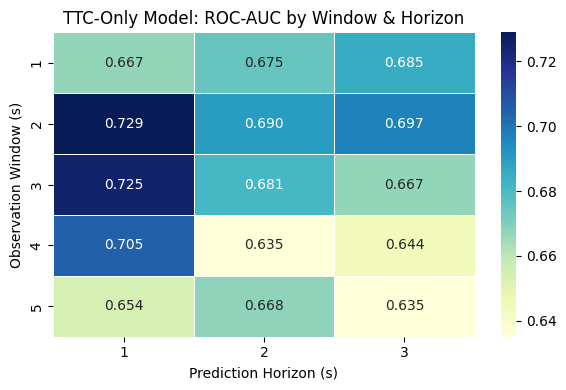

In [28]:
import warnings
warnings.filterwarnings("ignore")

window_sizes = [1, 2, 3, 4, 5]
horizons     = [1, 2, 3]

ttc_grid_results = []

for n in window_sizes:
    for h in horizons:
        # Build windowed dataset
        df_w = create_n_second_windows(df, n=n, feedback_horizon=h)
        df_w["TTC_capped"] = df_w["TTC_min"].clip(upper=20)
        df_w["TTC_log"]    = np.log1p(df_w["TTC_capped"])
        df_w = df_w.dropna(subset=["TTC_log", "feedback_next"])

        X      = df_w[["TTC_log"]].values
        y      = df_w["feedback_next"].values
        groups = df_w["Id"].values

        # Cross-validated AUC grouped by participant
        cv   = StratifiedGroupKFold(n_splits=5)
        aucs = []
        for tr, te in cv.split(X, y, groups):
            sc  = StandardScaler()
            Xtr = sc.fit_transform(X[tr])
            Xte = sc.transform(X[te])
            if y[te].sum() == 0:
                continue
            m = LogisticRegression(class_weight="balanced", max_iter=1000)
            m.fit(Xtr, y[tr])
            aucs.append(roc_auc_score(y[te], m.predict_proba(Xte)[:, 1]))

        if not aucs:
            continue

        ttc_grid_results.append({
            "Window (s)":  n,
            "Horizon (s)": h,
            "ROC-AUC":     round(np.mean(aucs), 3),
            "AUC SD":      round(np.std(aucs), 3),
            "n_rows":      len(df_w),
            "Pos rate (%)": round(y.mean() * 100, 2),
        })
        print(f"window={n}s, horizon={h}s → AUC={np.mean(aucs):.3f} (±{np.std(aucs):.3f})")

ttc_grid_df = pd.DataFrame(ttc_grid_results)

print()
print("=" * 60)
print("TTC-ONLY MODEL: Grid Search Results")
print("=" * 60)
print(ttc_grid_df.to_string(index=False))

# ── Heatmap ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
pivot = ttc_grid_df.pivot(index="Window (s)", columns="Horizon (s)", values="ROC-AUC")
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="YlGnBu", ax=ax, linewidths=0.5)
ax.set_title("TTC-Only Model: ROC-AUC by Window & Horizon")
ax.set_xlabel("Prediction Horizon (s)")
ax.set_ylabel("Observation Window (s)")
plt.tight_layout()
plt.show()

## distance delta

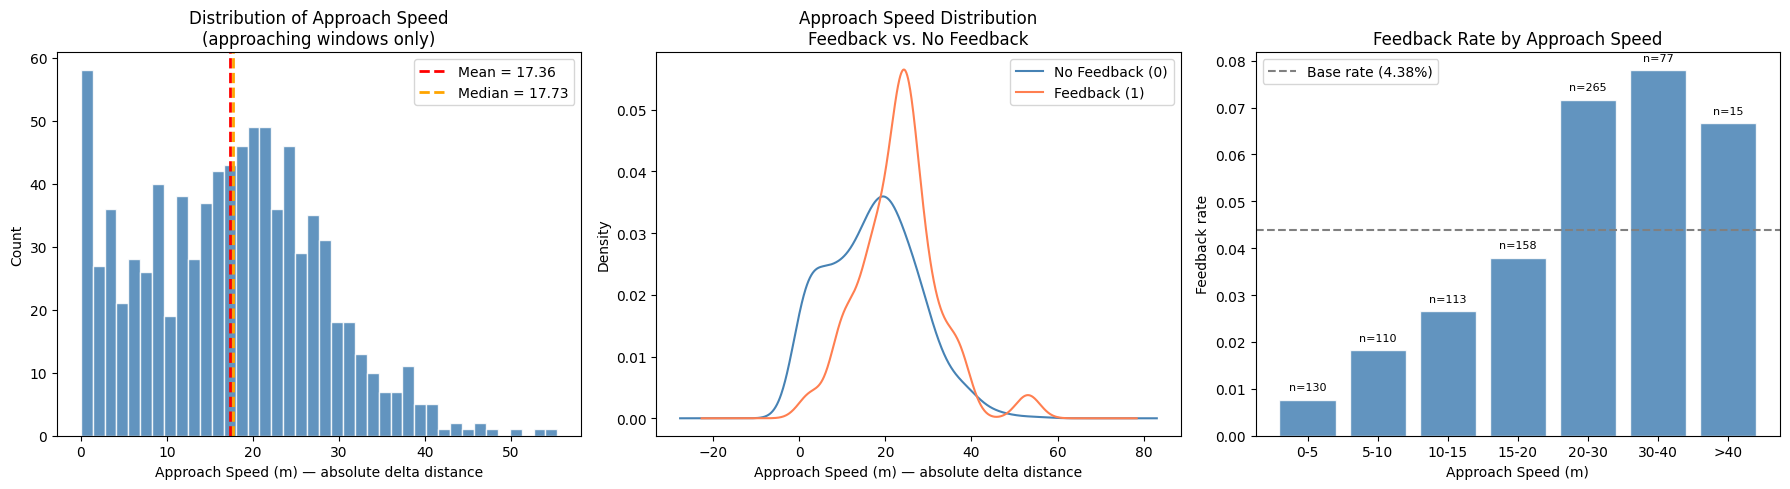

dist_bin  n_windows  n_feedback  feedback_rate
     0-5        130           1       0.007692
    5-10        110           2       0.018182
   10-15        113           3       0.026549
   15-20        158           6       0.037975
   20-30        265          19       0.071698
   30-40         77           6       0.077922
     >40         15           1       0.066667


In [29]:
# Filter to approaching windows only (negative delta_distance)
df_approach = df_5s[df_5s["delta_distance"] < 0].copy()
df_approach["delta_abs"] = df_approach["delta_distance"].abs()  # easier to read as "speed of approach"

delta = df_approach["delta_abs"]
fb0   = df_approach.loc[df_approach.feedback_next == 0, "delta_abs"]
fb1   = df_approach.loc[df_approach.feedback_next == 1, "delta_abs"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── 1. Histogram ──────────────────────────────────────────────────────
axes[0].hist(delta, bins=40, color="steelblue", edgecolor="white", alpha=0.85)
axes[0].axvline(delta.mean(),   color="red",    linestyle="--", lw=2, label=f"Mean = {delta.mean():.2f}")
axes[0].axvline(delta.median(), color="orange", linestyle="--", lw=2, label=f"Median = {delta.median():.2f}")
axes[0].set_xlabel("Approach Speed (m) — absolute delta distance")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of Approach Speed\n(approaching windows only)")
axes[0].legend()

# ── 2. KDE ────────────────────────────────────────────────────────────
fb0.plot.kde(ax=axes[1], label="No Feedback (0)", color="steelblue", bw_method=0.3)
fb1.plot.kde(ax=axes[1], label="Feedback (1)",    color="coral",     bw_method=0.3)
axes[1].set_xlabel("Approach Speed (m) — absolute delta distance")
axes[1].set_ylabel("Density")
axes[1].set_title("Approach Speed Distribution\nFeedback vs. No Feedback")
axes[1].legend()

# ── 3. Binned feedback rate ───────────────────────────────────────────
bin_edges  = [0, 5, 10, 15, 20, 30, 40, np.inf]
bin_labels = ["0-5", "5-10", "10-15", "15-20", "20-30", "30-40", ">40"]

df_approach["dist_bin"] = pd.cut(df_approach["delta_abs"], bins=bin_edges, labels=bin_labels)

bin_stats = df_approach.groupby("dist_bin", observed=True).agg(
    n_windows     = ("feedback_next", "count"),
    n_feedback    = ("feedback_next", "sum"),
    feedback_rate = ("feedback_next", "mean")
).reset_index()

axes[2].bar(bin_stats["dist_bin"], bin_stats["feedback_rate"],
            color="steelblue", edgecolor="white", alpha=0.85)
axes[2].axhline(df_approach["feedback_next"].mean(), color="gray", linestyle="--",
                label=f"Base rate ({df_approach['feedback_next'].mean()*100:.2f}%)")
axes[2].set_xlabel("Approach Speed (m)")
axes[2].set_ylabel("Feedback rate")
axes[2].set_title("Feedback Rate by Approach Speed")
axes[2].legend()

for _, row in bin_stats.iterrows():
    axes[2].text(row["dist_bin"], row["feedback_rate"] + 0.002,
                 f'n={int(row["n_windows"])}', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

print(bin_stats.to_string(index=False))

In [30]:
from sklearn.linear_model import LogisticRegression

# ── Logistic Regression (1s window, 1s horizon) ───────────────────────
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
folds_lr, summary_lr = run_pipeline(df, n=1, feedback_horizon=1,
                                    model=lr, k=5, use_l1_selection=False)

print()
print("=" * 65)
print("LOGISTIC REGRESSION (1s window, 1s horizon)")
print("=" * 65)
print(summary_lr.to_string(index=False))

Dataset: 5555 rows | 170 events | positive rate: 1.0%
Settings: n=1s, horizon=1s, k=5, L1=no

                   Mean                             SD                 
Threshold default (0.5) tuned (avg 0.82) default (0.5) tuned (avg 0.82)
Metric                                                                 
F1                0.044            0.041         0.016            0.038
Precision         0.023            0.023         0.008            0.021
ROC-AUC           0.685            0.685         0.073            0.073
Recall            0.550            0.200         0.176            0.186

LOGISTIC REGRESSION (1s window, 1s horizon)
       Threshold    Metric  Mean    SD
   default (0.5)   ROC-AUC 0.685 0.073
   default (0.5) Precision 0.023 0.008
   default (0.5)    Recall 0.550 0.176
   default (0.5)        F1 0.044 0.016
tuned (avg 0.82)   ROC-AUC 0.685 0.073
tuned (avg 0.82) Precision 0.023 0.021
tuned (avg 0.82)    Recall 0.200 0.186
tuned (avg 0.82)        F1 0.041 0.038


scale_pos_weight for XGBoost: 98
Dataset: 5555 rows | 170 events | positive rate: 1.0%
Settings: n=1s, horizon=1s, k=5, L1=no

                   Mean                             SD                 
Threshold default (0.5) tuned (avg 0.02) default (0.5) tuned (avg 0.02)
Metric                                                                 
F1                0.000            0.014         0.000            0.031
Precision         0.000            0.012         0.000            0.026
ROC-AUC           0.642            0.642         0.075            0.075
Recall            0.000            0.017         0.000            0.037
SVM C=0.1 → AUC=0.642 | F1=0.000
Dataset: 5555 rows | 170 events | positive rate: 1.0%
Settings: n=1s, horizon=1s, k=5, L1=no

                   Mean                             SD                 
Threshold default (0.5) tuned (avg 0.01) default (0.5) tuned (avg 0.01)
Metric                                                                 
F1                 0.00   

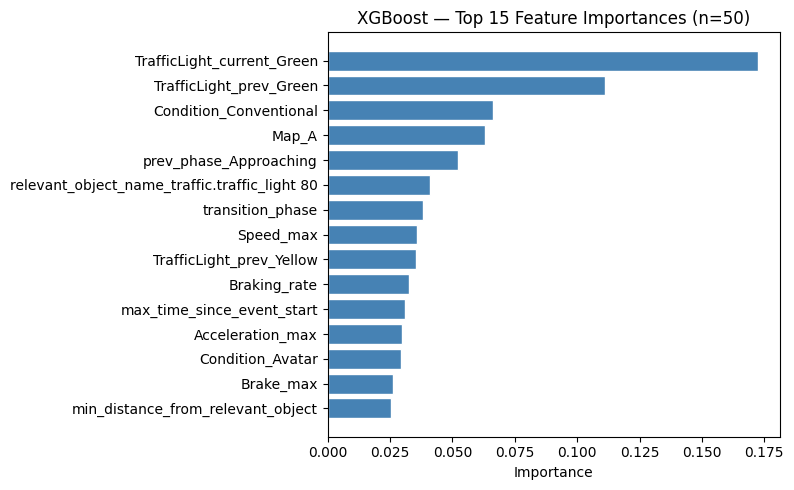

In [31]:
from sklearn.svm import SVC
from xgboost import XGBClassifier

# Compute scale_pos_weight for XGBoost from 1s data
df_1s_w = create_n_second_windows(df, n=1, feedback_horizon=1)
pos_rate = df_1s_w["feedback_next"].mean()
scale_pos_weight = round((1 - pos_rate) / pos_rate)
print(f"scale_pos_weight for XGBoost: {scale_pos_weight}")

# ── 1. SVM: grid search over C ────────────────────────────────────────
C_values = [0.1, 1, 10]
svm_results = []

for C in C_values:
    svm = SVC(kernel='rbf', C=C, class_weight='balanced',
              probability=True, random_state=42)
    folds_df, summary_df = run_pipeline(df, n=1, feedback_horizon=1,
                                        model=svm, k=5, use_l1_selection=False)
    sub = summary_df[summary_df["Threshold"] == "default (0.5)"].set_index("Metric")
    svm_results.append({
        "C":         C,
        "ROC-AUC":   sub.loc["ROC-AUC",   "Mean"],
        "AUC SD":    sub.loc["ROC-AUC",   "SD"],
        "Recall":    sub.loc["Recall",    "Mean"],
        "Precision": sub.loc["Precision", "Mean"],
        "F1":        sub.loc["F1",        "Mean"],
        "F1 SD":     sub.loc["F1",        "SD"],
    })
    print(f"SVM C={C} → AUC={sub.loc['ROC-AUC','Mean']:.3f} | F1={sub.loc['F1','Mean']:.3f}")

svm_df = pd.DataFrame(svm_results).round(3)
best_svm_row = svm_df.loc[svm_df["ROC-AUC"].idxmax()]

print()
print("=" * 65)
print("SVM: Results by C")
print("=" * 65)
print(svm_df.to_string(index=False))

# ── 2. XGBoost: grid search over n_estimators ────────────────────────
n_estimators_list = [50, 100, 200]
xgb_results = []

for n_est in n_estimators_list:
    xgb = XGBClassifier(scale_pos_weight=scale_pos_weight, n_estimators=n_est,
                        random_state=42, eval_metric='logloss')
    folds_df, summary_df = run_pipeline(df, n=1, feedback_horizon=1,
                                        model=xgb, k=5, use_l1_selection=False)
    sub = summary_df[summary_df["Threshold"] == "default (0.5)"].set_index("Metric")
    xgb_results.append({
        "n_estimators": n_est,
        "ROC-AUC":      sub.loc["ROC-AUC",   "Mean"],
        "AUC SD":       sub.loc["ROC-AUC",   "SD"],
        "Recall":       sub.loc["Recall",    "Mean"],
        "Precision":    sub.loc["Precision", "Mean"],
        "F1":           sub.loc["F1",        "Mean"],
        "F1 SD":        sub.loc["F1",        "SD"],
    })
    print(f"XGB n_estimators={n_est} → AUC={sub.loc['ROC-AUC','Mean']:.3f} | F1={sub.loc['F1','Mean']:.3f}")

xgb_df = pd.DataFrame(xgb_results).round(3)
best_xgb_row = xgb_df.loc[xgb_df["ROC-AUC"].idxmax()]

print()
print("=" * 65)
print("XGBOOST: Results by n_estimators")
print("=" * 65)
print(xgb_df.to_string(index=False))

# ── 3. Logistic Regression baseline ──────────────────────────────────
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
folds_lr, summary_lr = run_pipeline(df, n=1, feedback_horizon=1,
                                    model=lr, k=5, use_l1_selection=False)
sub_lr = summary_lr[summary_lr["Threshold"] == "default (0.5)"].set_index("Metric")

# ── 4. 3-way comparison table ─────────────────────────────────────────
comparison = pd.DataFrame([
    {
        "Model":     "Logistic Regression",
        "ROC-AUC":   sub_lr.loc["ROC-AUC",   "Mean"],
        "AUC SD":    sub_lr.loc["ROC-AUC",   "SD"],
        "Recall":    sub_lr.loc["Recall",    "Mean"],
        "Precision": sub_lr.loc["Precision", "Mean"],
        "F1":        sub_lr.loc["F1",        "Mean"],
        "F1 SD":     sub_lr.loc["F1",        "SD"],
    },
    {
        "Model":     f"SVM (C={best_svm_row['C']})",
        "ROC-AUC":   best_svm_row["ROC-AUC"],
        "AUC SD":    best_svm_row["AUC SD"],
        "Recall":    best_svm_row["Recall"],
        "Precision": best_svm_row["Precision"],
        "F1":        best_svm_row["F1"],
        "F1 SD":     best_svm_row["F1 SD"],
    },
    {
        "Model":     f"XGBoost (n={best_xgb_row['n_estimators']})",
        "ROC-AUC":   best_xgb_row["ROC-AUC"],
        "AUC SD":    best_xgb_row["AUC SD"],
        "Recall":    best_xgb_row["Recall"],
        "Precision": best_xgb_row["Precision"],
        "F1":        best_xgb_row["F1"],
        "F1 SD":     best_xgb_row["F1 SD"],
    },
]).round(3)

print()
print("=" * 65)
print("3-WAY COMPARISON: LR vs. SVM vs. XGBoost (1s window, 1s horizon)")
print("=" * 65)
print(comparison.to_string(index=False))

# ── 5. Feature importance: XGBoost ───────────────────────────────────
excl  = {'Id', 'event_id', 'window_index', 'start_time', 'end_time', 'window_size_sec', 'first_feedback_relavet_to_event', 'feedback_next'}
feats = [c for c in df_1s_w.columns if c not in excl]
X_all = pd.get_dummies(df_1s_w[feats])
y_all = df_1s_w["feedback_next"]

best_n_est = int(best_xgb_row["n_estimators"])
xgb_best = XGBClassifier(scale_pos_weight=scale_pos_weight,
                          n_estimators=best_n_est, random_state=42, eval_metric='logloss')
xgb_best.fit(X_all, y_all)

importance_df = pd.DataFrame({
    "Feature":    X_all.columns,
    "Importance": xgb_best.feature_importances_
}).sort_values("Importance", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(importance_df["Feature"][::-1], importance_df["Importance"][::-1],
        color="steelblue", edgecolor="white")
ax.set_title(f"XGBoost — Top 15 Feature Importances (n={best_n_est})")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

# Survival Analysis — Feature Selection
### Univariate Cox + Lasso Cox

In [32]:
from lifelines import CoxTimeVaryingFitter, KaplanMeierFitter
from lifelines.statistics import logrank_test

def prepare_survival_data(df, extra_cols=[]):
    """
    Converts 1-second sliding windows into survival format.
    Each event_id is truncated at the first feedback occurrence.
    """
    base_cols = ['event_id', 'Id', 'start_time', 'end_time',
                 'TTC_min', 'delta_distance', 'Speed_mean', 'Brake_max',
                 'SteeringAngle_absmax', 'yellow_transition', 'transition_phase'] + extra_cols

    records = []
    for eid, edf in df.groupby("event_id"):
        edf = edf.sort_values("window_index").reset_index(drop=True)

        feedback_rows = edf[edf["feedback_next_1s"] == 1]
        if len(feedback_rows) > 0:
            # Keep rows up to and including first feedback
            first_idx = feedback_rows.index[0]
            edf_trim = edf.loc[:first_idx].copy()
            edf_trim["event"] = 0
            edf_trim.loc[first_idx, "event"] = 1
        else:
            # Censored — no feedback occurred
            edf_trim = edf.copy()
            edf_trim["event"] = 0

        records.append(edf_trim)

    result = pd.concat(records, ignore_index=True)
    result["TTC_capped"] = result["TTC_min"].clip(upper=20)
    result["TTC_log"]    = np.log1p(result["TTC_capped"])
    return result

df_surv = prepare_survival_data(df)
print(f"Total rows: {len(df_surv)}")
print(f"Total events (feedback): {df_surv['event'].sum()}")
print(f"Total subjects (event_ids): {df_surv['event_id'].nunique()}")

Total rows: 5499
Total events (feedback): 56
Total subjects (event_ids): 170


Dropping zero-variance features: ['SteeringAngle_absmax', 'SteeringAngle_std']
Total feedback events: 56
Total variables:       27
Events per variable:   2.1

OPTION 1: Univariate Cox — one variable at a time
                          Feature    HR  CI lower  CI upper  p-value  significant
                        Brake_max 1.207     1.071     1.361   0.0021         True
                   TL_prev_Yellow 1.246     1.073     1.447   0.0039         True
                TL_current_Yellow 1.242     1.069     1.444   0.0046         True
                   TL_current_Red 1.251     1.038     1.508   0.0187         True
                     Braking_rate 1.153     0.982     1.353   0.0823        False
                      TL_prev_Red 1.178     0.977     1.420   0.0858        False
                yellow_transition 1.129     0.980     1.301   0.0938        False
min_distance_from_relevant_object 0.829     0.656     1.047   0.1149        False
                 Acceleration_min 1.125     0.956    

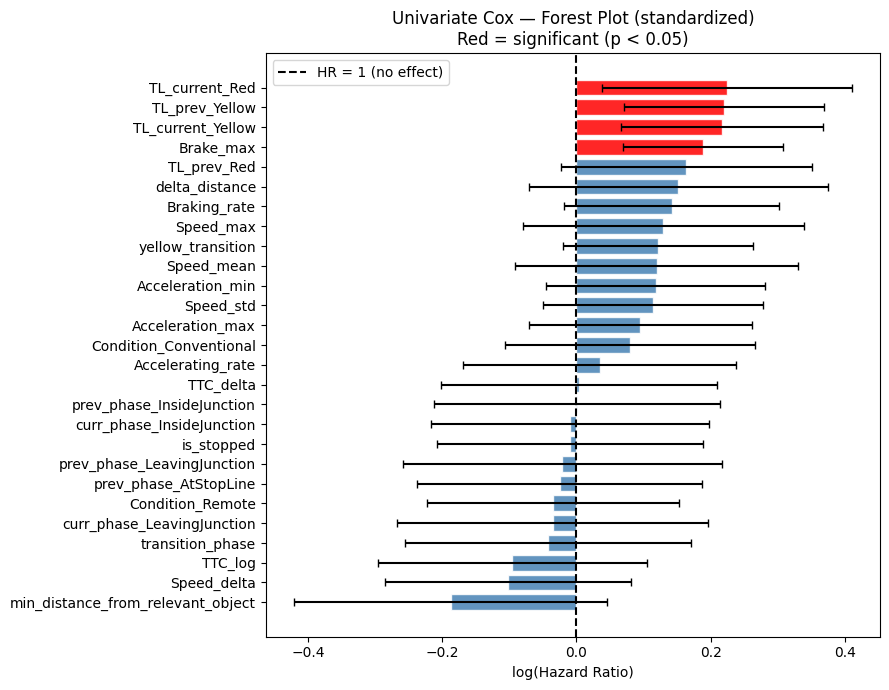

In [54]:

from lifelines import CoxTimeVaryingFitter
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")

# ── Prepare data ──────────────────────────────────────────────────────
df_surv_fs = prepare_survival_data(df)
condition_dummies = pd.get_dummies(df_surv_fs["Condition"], prefix="Condition", drop_first=True)
df_surv_fs = pd.concat([df_surv_fs, condition_dummies], axis=1)

trafficlight_prev_dummies    = pd.get_dummies(df_surv_fs["TrafficLight_prev"],    prefix="TL_prev",    drop_first=True)
trafficlight_current_dummies = pd.get_dummies(df_surv_fs["TrafficLight_current"], prefix="TL_current", drop_first=True)
prev_phase_dummies           = pd.get_dummies(df_surv_fs["prev_phase"],           prefix="prev_phase", drop_first=True)
current_phase_dummies        = pd.get_dummies(df_surv_fs["current_phase"],        prefix="curr_phase", drop_first=True)

df_surv_fs = pd.concat([
    df_surv_fs,
    trafficlight_prev_dummies,
    trafficlight_current_dummies,
    prev_phase_dummies,
    current_phase_dummies
], axis=1)

all_features = [
    "TTC_log", "delta_distance", "min_distance_from_relevant_object",
    "Brake_max", "Braking_rate", "Acceleration_max", "Acceleration_min",
    "Accelerating_rate", "Speed_mean", "Speed_max", "Speed_std", "Speed_delta",
    "is_stopped", "SteeringAngle_absmax", "SteeringAngle_std",
    "TTC_delta", "yellow_transition", "transition_phase"
] + list(condition_dummies.columns) \
  + list(trafficlight_prev_dummies.columns) \
  + list(trafficlight_current_dummies.columns) \
  + list(prev_phase_dummies.columns) \
  + list(current_phase_dummies.columns)

df_surv_fs[all_features] = df_surv_fs[all_features].fillna(0)

# ── Drop zero-variance features ───────────────────────────────────────
zero_var = [f for f in all_features if df_surv_fs[f].std() == 0]
if zero_var:
    print(f"Dropping zero-variance features: {zero_var}")
    all_features = [f for f in all_features if f not in zero_var]

# ── Standardize all features ──────────────────────────────────────────
scaler = StandardScaler()
df_surv_fs[all_features] = scaler.fit_transform(df_surv_fs[all_features])

print(f"Total feedback events: {df_surv_fs['event'].sum()}")
print(f"Total variables:       {len(all_features)}")
print(f"Events per variable:   {df_surv_fs['event'].sum() / len(all_features):.1f}")

# ── Option 1: Univariate Cox ──────────────────────────────────────────
print()
print("=" * 60)
print("OPTION 1: Univariate Cox — one variable at a time")
print("=" * 60)

univariate_results = []

for feat in all_features:
    try:
        cols  = ["event_id", "start_time", "end_time", "event", feat]
        model = CoxTimeVaryingFitter(penalizer=0.01)
        model.fit(df_surv_fs[cols], id_col="event_id",
                  start_col="start_time", stop_col="end_time", event_col="event")
        s = model.summary
        univariate_results.append({
            "Feature":     feat,
            "HR":          round(np.exp(s["coef"].values[0]), 3),
            "CI lower":    round(np.exp(s["coef lower 95%"].values[0]), 3),
            "CI upper":    round(np.exp(s["coef upper 95%"].values[0]), 3),
            "p-value":     round(s["p"].values[0], 4),
            "significant": s["p"].values[0] < 0.05
        })
    except Exception as e:
        print(f"  Skipped {feat}: {e}")

uni_df = pd.DataFrame(univariate_results).sort_values("p-value")
print(uni_df.to_string(index=False))

univariate_selected = uni_df[uni_df["significant"]]["Feature"].tolist()
print(f"\nSelected (p < 0.05): {univariate_selected}")

# ── Option 2: Lasso Cox ───────────────────────────────────────────────
print()
print("=" * 60)
print("OPTION 2: Lasso Cox — automatic selection")
print("=" * 60)

cols_all  = ["event_id", "start_time", "end_time", "event"] + all_features
lasso_cox = CoxTimeVaryingFitter(penalizer=1.0, l1_ratio=1.0)
lasso_cox.fit(df_surv_fs[cols_all], id_col="event_id",
              start_col="start_time", stop_col="end_time", event_col="event")

lasso_summary  = lasso_cox.summary.copy()
lasso_selected = lasso_summary[lasso_summary["coef"].abs() > 0.001].index.tolist()

print(lasso_summary[["coef", "exp(coef)", "p"]].round(4).to_string())
print(f"\nSurviving features (|coef| > 0.001): {lasso_selected}")

# ── Overlap ───────────────────────────────────────────────────────────
print()
print("=" * 60)
print("OVERLAP: Univariate + Lasso")
print("=" * 60)

overlap = list(set(univariate_selected) & set(lasso_selected))
print(f"Univariate selected: {len(univariate_selected)} → {univariate_selected}")
print(f"Lasso selected:      {len(lasso_selected)} → {lasso_selected}")
print(f"Overlap:             {len(overlap)} → {sorted(overlap)}")

# ── Forest plot ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
uni_plot = uni_df.sort_values("HR")
colors   = ["red" if s else "steelblue" for s in uni_plot["significant"]]

ax.barh(uni_plot["Feature"], np.log(uni_plot["HR"]),
        xerr=[np.log(uni_plot["HR"]) - np.log(uni_plot["CI lower"]),
              np.log(uni_plot["CI upper"]) - np.log(uni_plot["HR"])],
        color=colors, edgecolor="white", alpha=0.85, capsize=3)
ax.axvline(0, color="black", linestyle="--", lw=1.5, label="HR = 1 (no effect)")
ax.set_xlabel("log(Hazard Ratio)")
ax.set_title("Univariate Cox — Forest Plot (standardized)\nRed = significant (p < 0.05)")
ax.legend()
plt.tight_layout()
plt.show()


Fold 1: C-index = 0.726
Fold 2: C-index = 0.610
Fold 3: C-index = 0.714
Fold 4: C-index = 0.681
Fold 5: C-index = 0.612


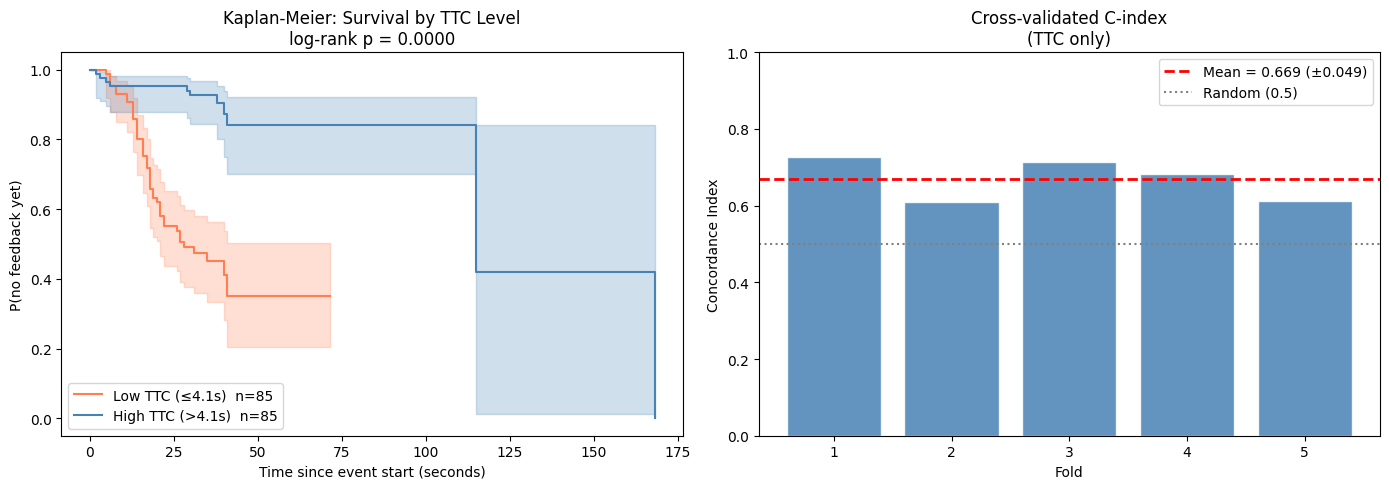


ACCURACY SUMMARY — TTC only
C-index mean:  0.669
C-index SD:    0.049
Log-rank p:    0.0000
Significant:   Yes


In [55]:
# ── KM Curves: split by high/low TTC ─────────────────────────────────
median_ttc = df_surv.groupby("event_id")["TTC_capped"].mean().median()

event_summary = df_surv.groupby("event_id").agg(
    duration = ("end_time",   "max"),
    event    = ("event",      "max"),
    mean_ttc = ("TTC_capped", "mean")
).reset_index()

low_ttc  = event_summary[event_summary["mean_ttc"] <= median_ttc]
high_ttc = event_summary[event_summary["mean_ttc"] >  median_ttc]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: KM curves ───────────────────────────────────────────────────
kmf = KaplanMeierFitter()

kmf.fit(low_ttc["duration"], low_ttc["event"],
        label=f"Low TTC (≤{median_ttc:.1f}s)  n={len(low_ttc)}")
kmf.plot_survival_function(ax=axes[0], ci_show=True, color="coral")

kmf.fit(high_ttc["duration"], high_ttc["event"],
        label=f"High TTC (>{median_ttc:.1f}s)  n={len(high_ttc)}")
kmf.plot_survival_function(ax=axes[0], ci_show=True, color="steelblue")

lr = logrank_test(low_ttc["duration"],  high_ttc["duration"],
                  low_ttc["event"],     high_ttc["event"])

axes[0].set_title(f"Kaplan-Meier: Survival by TTC Level\nlog-rank p = {lr.p_value:.4f}")
axes[0].set_xlabel("Time since event start (seconds)")
axes[0].set_ylabel("P(no feedback yet)")

# ── Right: Concordance index per fold ─────────────────────────────────
from sklearn.model_selection import StratifiedGroupKFold

X_surv  = df_surv[["TTC_log"]].copy()
y_event = df_surv["event"].values
groups  = df_surv["Id"].values

cv    = StratifiedGroupKFold(n_splits=5)
c_indices = []

for fold, (tr, te) in enumerate(cv.split(X_surv, y_event, groups)):
    df_tr = df_surv.iloc[tr].copy()
    df_te = df_surv.iloc[te].copy()

    if df_te["event"].sum() == 0:
        continue

    model = CoxTimeVaryingFitter(penalizer=0.1)
    model.fit(df_tr[["event_id", "start_time", "end_time", "event", "TTC_log"]],
              id_col="event_id", start_col="start_time",
              stop_col="end_time", event_col="event")

    ph = model.predict_log_partial_hazard(
        df_te[["event_id", "start_time", "end_time", "event", "TTC_log"]]
    ).values

    df_te = df_te.copy()
    df_te["ph"] = ph
    summary_te = df_te.groupby("event_id").agg(
        duration = ("end_time", "max"),
        event    = ("event",    "max"),
        mean_ph  = ("ph",       "mean")
    ).reset_index()

    c = concordance_index(summary_te["duration"],
                          -summary_te["mean_ph"],
                          summary_te["event"])
    c_indices.append(c)
    print(f"Fold {fold+1}: C-index = {c:.3f}")

axes[1].bar(range(1, len(c_indices)+1), c_indices,
            color="steelblue", edgecolor="white", alpha=0.85)
axes[1].axhline(np.mean(c_indices), color="red", linestyle="--", lw=2,
                label=f"Mean = {np.mean(c_indices):.3f} (±{np.std(c_indices):.3f})")
axes[1].axhline(0.5, color="gray", linestyle=":", lw=1.5, label="Random (0.5)")
axes[1].set_xlabel("Fold")
axes[1].set_ylabel("Concordance Index")
axes[1].set_title("Cross-validated C-index\n(TTC only)")
axes[1].set_ylim(0, 1)
axes[1].legend()

plt.tight_layout()
plt.show()

print()
print("=" * 45)
print("ACCURACY SUMMARY — TTC only")
print("=" * 45)
print(f"C-index mean:  {np.mean(c_indices):.3f}")
print(f"C-index SD:    {np.std(c_indices):.3f}")
print(f"Log-rank p:    {lr.p_value:.4f}")
print(f"Significant:   {'Yes' if lr.p_value < 0.05 else 'No'}")

In [ ]:
df_surv.head()

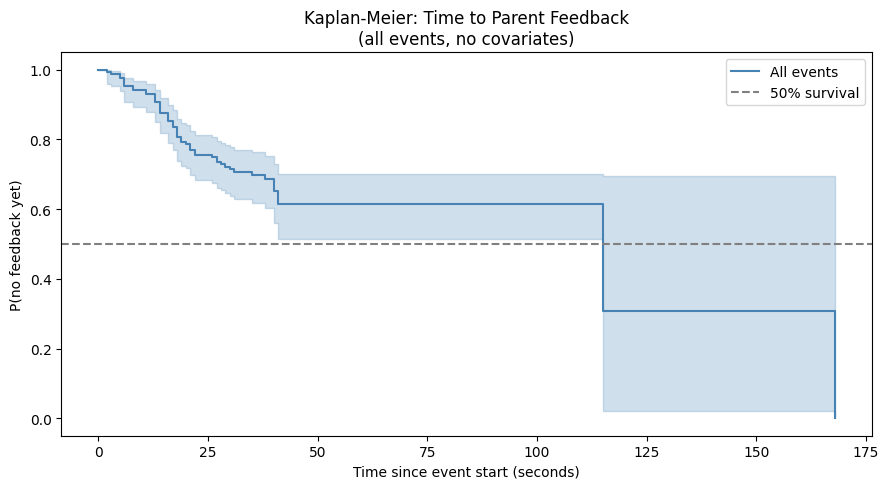

Median survival time: 115.0 seconds
Total events: 170
Feedback events: 56
Censored: 114


In [56]:
from lifelines import KaplanMeierFitter

event_summary = df_surv.groupby("event_id").agg(
    duration = ("end_time", "max"),
    event    = ("event",    "max")
).reset_index()

kmf = KaplanMeierFitter()
kmf.fit(event_summary["duration"], event_summary["event"], label="All events")

fig, ax = plt.subplots(figsize=(9, 5))
kmf.plot_survival_function(ax=ax, ci_show=True, color="steelblue")

ax.set_title("Kaplan-Meier: Time to Parent Feedback\n(all events, no covariates)")
ax.set_xlabel("Time since event start (seconds)")
ax.set_ylabel("P(no feedback yet)")
ax.axhline(0.5, color="gray", linestyle="--", label="50% survival")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Median survival time: {kmf.median_survival_time_:.1f} seconds")
print(f"Total events: {len(event_summary)}")
print(f"Feedback events: {event_summary['event'].sum()}")
print(f"Censored: {(event_summary['event'] == 0).sum()}")

# Trying multiple variables survival analysis

In [57]:
# Check exact column names available
import warnings
warnings.filterwarnings("ignore")

# The dummy columns were created with these prefixes:
# prev_phase_ and curr_phase_
# So "current_phase_Approaching" → "curr_phase_Approaching"
# and TTC_min needs to be added (we used TTC_log before)

# Add TTC_min and cap it, then standardize
df_surv_fs["TTC_min_scaled"] = scaler.fit_transform(df_surv_fs[["TTC_capped"]])

selected_features = [
    "Acceleration_min",
    "curr_phase_Approaching",   # renamed from current_phase_Approaching
    "delta_distance",
    "prev_phase_Approaching",
    "prev_phase_InsideJunction",
    "transition_phase",
    "TTC_min_scaled",           # TTC_min capped and scaled
]

# Verify all columns exist
missing = [f for f in selected_features if f not in df_surv_fs.columns]
print("Missing columns:", missing)
print("Available columns:", [c for c in df_surv_fs.columns if "phase" in c or "TTC" in c])

Missing columns: ['curr_phase_Approaching', 'prev_phase_Approaching']
Available columns: ['TTC_min', 'TTC_mean', 'TTC_delta', 'prev_phase', 'current_phase', 'transition_phase', 'TTC_capped', 'TTC_log', 'prev_phase_AtStopLine', 'prev_phase_InsideJunction', 'prev_phase_LeavingJunction', 'curr_phase_InsideJunction', 'curr_phase_LeavingJunction', 'TTC_min_scaled']


In [58]:
selected_features = [
    "Acceleration_min",
    "prev_phase_InsideJunction",   # was prev_phase_Approaching (reference category)
    "prev_phase_LeavingJunction",  # other available prev_phase dummies
    "curr_phase_InsideJunction",   # available current_phase dummies
    "curr_phase_LeavingJunction",
    "delta_distance",
    "transition_phase",
    "TTC_min_scaled",
]

# Verify
missing = [f for f in selected_features if f not in df_surv_fs.columns]
print("Missing columns:", missing)  # should be []

Missing columns: []


<lifelines.CoxTimeVaryingFitter: fitted with 5499 periods, 170 subjects, 56 events>
         event col = 'event'
         penalizer = 0.1
number of subjects = 170
 number of periods = 5499
  number of events = 56
partial log-likelihood = -260.52
  time fit was run = 2026-06-07 21:21:38 UTC

---
                            coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                   
Acceleration_min            0.03      1.03      0.04           -0.05            0.10                0.95                1.11
prev_phase_InsideJunction   0.00      1.00      0.04           -0.08            0.08                0.92                1.09
prev_phase_LeavingJunction -0.00      1.00      0.04           -0.08            0.08                0.92                1.08
curr_phase_InsideJunction  -0.00      1.00      0.04           -0.08            0.08                0.92                1.08
curr_phase_LeavingJunction -0.00      1.00      0.04           -0.09            0.08                0.92                1.08
delta_distance              0.02      1.02      0.04           -0.06            0.10                0.94                1.11
transition_phase           -0.01      0.99      0.04           -0.09            0.08                0.92                1.08
TTC_min_scaled             -0.01      0.99      0.04           -0.09            0.08                0.92                1.08

                            cmp to     z    p  -log2(p)
covariate                                              
Acceleration_min              0.00  0.63 0.53      0.93
prev_phase_InsideJunction     0.00  0.02 0.99      0.02
prev_phase_LeavingJunction    0.00 -0.06 0.95      0.07
curr_phase_InsideJunction     0.00 -0.02 0.98      0.02
curr_phase_LeavingJunction    0.00 -0.11 0.92      0.13
delta_distance                0.00  0.49 0.63      0.67
transition_phase              0.00 -0.15 0.88      0.18
TTC_min_scaled                0.00 -0.13 0.90      0.16
---
Partial AIC = 537.04
log-likelihood ratio test = 0.71 on 8 df
-log2(p) of ll-ratio test = 0.00

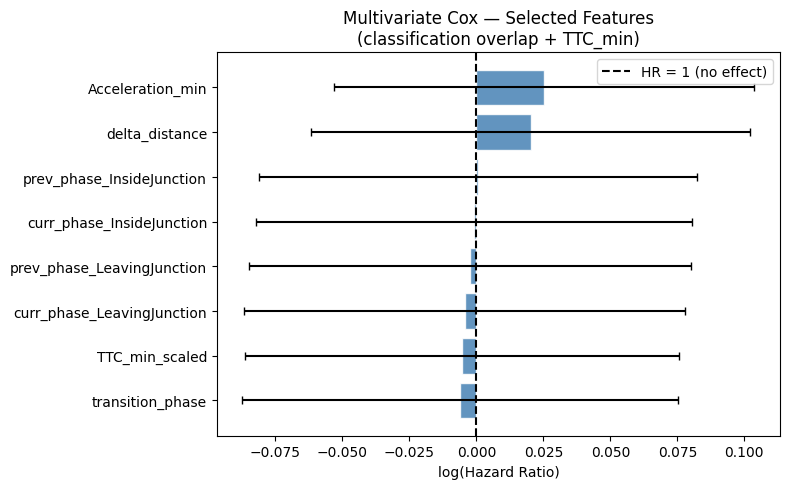

Fold 1: C-index = 0.809
Fold 2: C-index = 0.795
Fold 3: C-index = 0.921
Fold 4: C-index = 0.832
Fold 5: C-index = 0.829

MULTIVARIATE COX — ACCURACY SUMMARY
C-index mean:  0.837
C-index SD:    0.044
TTC only mean: 0.669
Improvement:   0.168


In [59]:
cols = ["event_id", "start_time", "end_time", "event"] + selected_features

multi_cox = CoxTimeVaryingFitter(penalizer=0.1)
multi_cox.fit(
    df_surv_fs[cols],
    id_col="event_id",
    start_col="start_time",
    stop_col="end_time",
    event_col="event"
)

multi_cox.print_summary()

# ── Forest plot ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

summary = multi_cox.summary.copy()
summary["HR"]       = np.exp(summary["coef"])
summary["CI_lower"] = np.exp(summary["coef lower 95%"])
summary["CI_upper"] = np.exp(summary["coef upper 95%"])
summary = summary.sort_values("coef")

colors = ["red" if p < 0.05 else "steelblue" for p in summary["p"]]

ax.barh(summary.index, np.log(summary["HR"]),
        xerr=[np.log(summary["HR"]) - np.log(summary["CI_lower"]),
              np.log(summary["CI_upper"]) - np.log(summary["HR"])],
        color=colors, edgecolor="white", alpha=0.85, capsize=3)

ax.axvline(0, color="black", linestyle="--", lw=1.5, label="HR = 1 (no effect)")
ax.set_xlabel("log(Hazard Ratio)")
ax.set_title("Multivariate Cox — Selected Features\n(classification overlap + TTC_min)")
ax.legend()
plt.tight_layout()
plt.show()

# ── Cross-validated C-index ───────────────────────────────────────────
cv = StratifiedGroupKFold(n_splits=5)
c_indices_multi = []

for fold, (tr, te) in enumerate(cv.split(df_surv_fs, df_surv_fs["event"], df_surv_fs["Id"])):
    df_tr = df_surv_fs.iloc[tr].copy()
    df_te = df_surv_fs.iloc[te].copy()

    if df_te["event"].sum() == 0:
        continue

    model = CoxTimeVaryingFitter(penalizer=0.1)
    model.fit(df_tr[cols], id_col="event_id",
              start_col="start_time", stop_col="end_time", event_col="event")

    ph = model.predict_log_partial_hazard(df_te[cols]).values
    df_te = df_te.copy()
    df_te["ph"] = ph

    summary_te = df_te.groupby("event_id").agg(
        duration = ("end_time", "max"),
        event    = ("event",    "max"),
        mean_ph  = ("ph",       "mean")
    ).reset_index()

    c = concordance_index(summary_te["duration"],
                          -summary_te["mean_ph"],
                          summary_te["event"])
    c_indices_multi.append(c)
    print(f"Fold {fold+1}: C-index = {c:.3f}")

print()
print("=" * 50)
print("MULTIVARIATE COX — ACCURACY SUMMARY")
print("=" * 50)
print(f"C-index mean:  {np.mean(c_indices_multi):.3f}")
print(f"C-index SD:    {np.std(c_indices_multi):.3f}")
print(f"TTC only mean: {np.mean(c_indices):.3f}")
print(f"Improvement:   {np.mean(c_indices_multi) - np.mean(c_indices):.3f}")

# Feedback Timing — When Does Feedback Occur Within an Event?

Total feedback windows: 56
Unique events with feedback: 56
Time of feedback (start_time) stats:
count     56.00
mean      21.95
std       25.57
min        1.00
25%       12.00
50%       16.50
75%       25.25
max      167.00
Name: start_time, dtype: float64


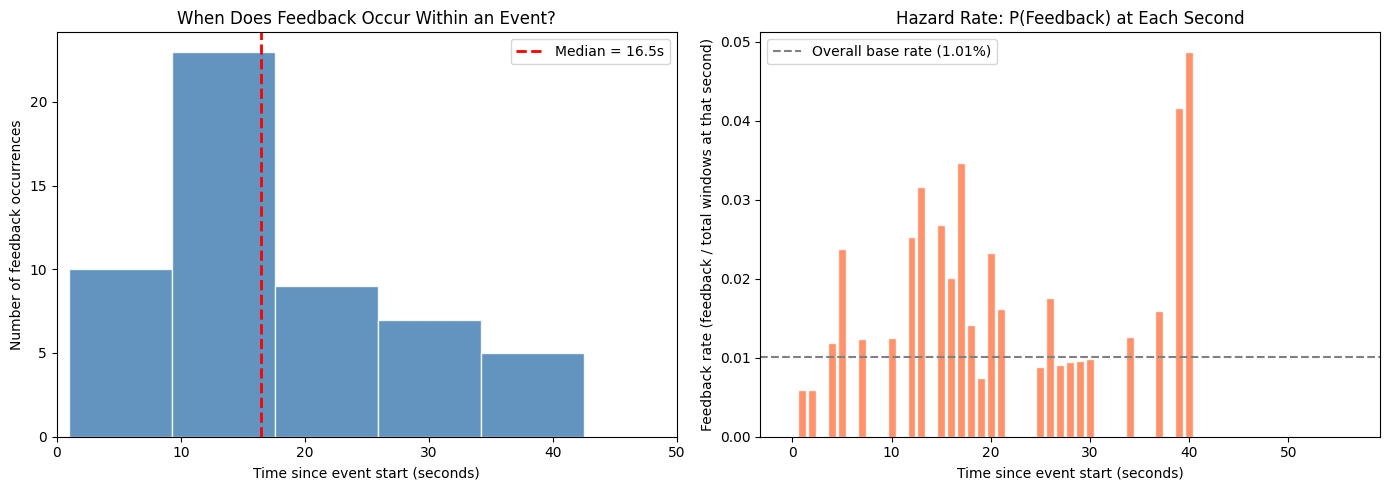


Feedback count by time bin:
time_bin
0-5s       8
5-10s      4
10-15s    13
15-20s    14
20-30s     9
30s+       8


In [60]:
# Load 1-second data
df_1s = pd.read_csv("sliding_windows_1s_clean.csv")
df_1s["event_id"] = df_1s["event_id"].str.lower()

# Keep only windows where feedback occurs in the next second
feedback_rows = df_1s[df_1s["feedback_next_1s"] == 1].copy()

print("Total feedback windows:", len(feedback_rows))
print("Unique events with feedback:", feedback_rows["event_id"].nunique())
print("Time of feedback (start_time) stats:")
print(feedback_rows["start_time"].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: histogram of feedback timing ───────────────────────────────
axes[0].hist(feedback_rows["start_time"], bins=20, color="steelblue",
             edgecolor="white", alpha=0.85)
axes[0].set_xlim(0, 50)
axes[0].set_xlabel("Time since event start (seconds)")
axes[0].set_ylabel("Number of feedback occurrences")
axes[0].set_title("When Does Feedback Occur Within an Event?")
axes[0].axvline(feedback_rows["start_time"].median(), color="red",
                linestyle="--", lw=2,
                label="Median = " + str(round(feedback_rows["start_time"].median(), 1)) + "s")
axes[0].legend()

# ── Right: feedback rate per second (hazard over time) ───────────────
# At each second t: how many times did feedback happen / how many windows existed
total_per_sec = df_1s.groupby("start_time").size()
feedback_per_sec = feedback_rows.groupby("start_time").size()
hazard = (feedback_per_sec / total_per_sec).fillna(0)

# Only show seconds that have at least 5 windows (enough data)
hazard_filtered = hazard[total_per_sec >= 5]

axes[1].bar(hazard_filtered.index, hazard_filtered.values,
            color="coral", edgecolor="white", alpha=0.85, width=0.8)
axes[1].set_xlabel("Time since event start (seconds)")
axes[1].set_ylabel("Feedback rate (feedback / total windows at that second)")
axes[1].set_title("Hazard Rate: P(Feedback) at Each Second")
axes[1].axhline(df_1s["feedback_next_1s"].mean(), color="gray",
                linestyle="--", lw=1.5,
                label="Overall base rate (" + str(round(df_1s["feedback_next_1s"].mean()*100, 2)) + "%)")
axes[1].legend()

plt.tight_layout()
plt.show()

# Summary table per time bin
bins = [0, 5, 10, 15, 20, 30, 999]
labels = ["0-5s", "5-10s", "10-15s", "15-20s", "20-30s", "30s+"]
feedback_rows["time_bin"] = pd.cut(feedback_rows["start_time"], bins=bins, labels=labels)
print()
print("Feedback count by time bin:")
print(feedback_rows["time_bin"].value_counts().sort_index().to_string())
